In [2]:
from nltk import Tree
import numpy as np
from itertools import combinations_with_replacement
import random
import itertools
import pandas as pd
import nltk 
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk import pos_tag
from nltk import RegexpParser
from nltk.tokenize import sent_tokenize 
from nltk import Tree
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet as wn
from IPython.display import display
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from transformers import TFBertModel, AutoTokenizer
from transformers import GPT2Tokenizer, GPT2LMHeadModel
from sentence_transformers import SentenceTransformer
from sklearn.cluster import DBSCAN
from scipy.spatial.distance import cosine
from concurrent.futures import ProcessPoolExecutor
import warnings
import time
from concurrent.futures import ThreadPoolExecutor
from transformers import logging
from matplotlib.ticker import MaxNLocator
import math
from transformers import pipeline
from functools import partial
from scipy.optimize import curve_fit
import json
import itertools

from collections import defaultdict
from scipy.interpolate import make_interp_spline
from matplotlib.collections import LineCollection
from collections import Counter
from scipy.interpolate import interp1d
from scipy.interpolate import CubicSpline
from scipy.interpolate import PchipInterpolator


warnings.filterwarnings('ignore')
logging.set_verbosity_error()  # disable warnings from transformer, hugging face package.

## Manual chunking on narrative 4.

In [3]:
## get all the stories.  nine stories in total.
story_all = [] 

data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/boyscout.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/schissel_v1-pool.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/schissel_v2-lake.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/triplett_v1-rookie.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/triplett_v2-catlady.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/panic.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/hester_v1-park.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/hester_v2-church.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/stein.pkl")
story_all.append(data)

In [4]:
## use the clauses in the original dataset.
story_processed_all = [story_all[i]['segmentation'] for i in np.arange(9)]
story_processed_marked = [string.split("\n") for string in story_processed_all]  # split into single clauses.
story_processed_all_num = story_processed_marked

story_processed_all = [[item[3:] if item[2] == "." 
                        else item[2:] if item[1] == "."
                        else item[4:] for item in story_processed_marked[story]] for story in np.arange(9)]

recall_processed_all = [story_all[i]['recalls segmented'] for i in np.arange(len(story_processed_all))]
recall_processed_marked = [[participant.split("\n") for participant in recall_processed_all[story]]
                        for story in np.arange(9)]
recall_processed_all = [[ [element[3:] if len(element) > 2 and element[2] == "." else
                           element[2:] if len(element) > 2 and element[1] == "." else
                           element[4:] if len(element) > 2 else
                           ""  for element in participant] for participant in recall_processed_marked[story]]
                        for story in np.arange(9)]

score_processed_all = [story_all[i]['recall scores'] for i in np.arange(len(story_processed_all))]
for i in np.arange(len(score_processed_all)):
    recall_score_each = score_processed_all[i].values
    score_processed_all[i] = recall_score_each.tolist()

In [5]:
## three more stories added to the analysis.
story_additional = [] 
recall_additional = []

data = pd.read_csv("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/bear-segments.csv", encoding='ISO-8859-1')
story_additional.append(data)
recall = pd.read_csv("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/bear-recalls_segmented.csv", encoding='ISO-8859-1')
recall_additional.append(recall)

data = pd.read_csv("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/costa-segments.csv", encoding='utf-8')
story_additional.append(data)
recall = pd.read_csv("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/costa-recalls_segmented.csv", encoding='utf-8')
recall_additional.append(recall)

data = pd.read_csv("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/do-something-segments.csv", encoding='ISO-8859-1')
story_additional.append(data)
recall = pd.read_csv("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/dosomething-recalls_segmented.csv", encoding='ISO-8859-1')
recall_additional.append(recall)

In [6]:
additional_story_processed = []
additional_recall_processed = [[] for _ in np.arange(3)]
score_processed_additional = []

for i in np.arange(3):
    # the original story in segment.
    story = story_additional[i]['segment_text']
    story_as_list = story.tolist()
    additional_story_processed.append(story_as_list)

    # get the recall text by each participant.
    recall = recall_additional[i]
    recall_id = recall['recall_id']
    recall_id_set = list(set(recall_id))
    for j in recall_id_set:
        recall_participant = recall[recall['recall_id'] == j]
        recall_content = recall_participant['clause_text']
        recall_as_list = recall_content.tolist()
        additional_recall_processed[i].append(recall_as_list)

    # get the recall score of each narrative clause. - the final score in the csv directly.
    score_processed_additional.append(story_additional[i]['proc'])
    score_processed_add = [series_item.tolist() for series_item in score_processed_additional]
    score_processed = [[float(p.strip('%')) for p in percent_list] 
                                      for percent_list in score_processed_add]

In [7]:
## add the new data to the dataset.
story_processed_all = story_processed_all + additional_story_processed
# print(len(story_processed_all))

story_processed_all_num = story_processed_all_num + additional_story_processed

recall_processed_all = recall_processed_all + additional_recall_processed
# print(len(recall_processed_all))

clauses = [len(story_processed_all[i]) for i in np.arange(len(story_processed_all))]
print("clauses in each story: ", clauses )

clauses in each story:  [19, 18, 18, 32, 32, 56, 54, 54, 130, 122, 194, 81]


## Simulation functions with a given initial N, and branching into 4 at each layer.

In [8]:
partition_bars = 3    # K value. divide into K-1 groups.
groups = partition_bars + 1       # the max std to normalize change with the "groups" number. need to change the code beneath.
initial_clause = 80   # total number of clauses in the story. a trial. following code uses different total numbers of clauses.

scenario_number = []

In [9]:
## get a random scenario.
def ball_location_simulation(parent_clause):
    num_locations = parent_clause + partition_bars 
    bar_location = random.sample(range(0, num_locations), k=partition_bars)   # generate three random numbers between 0 and 40+3-1, cannot repeat.
                                                           # partition_bars is a public variable.

    box_assignments = np.zeros(num_locations, dtype=int)
    box_assignments[bar_location] = 1
     
    return box_assignments   # too much boxes, less likely to have them at one place.

def calculate_clauses(assignment):
    # print(assignment)
    # find the index difference between the first, 1, the last number in the list. as number of clauses in each box.
    indices_of_ones = []
    # if np.all(assignment < 2):   # no 0 clause situation.
    indices_of_ones = [index for index, value in enumerate(assignment) if value == 1]

    nodes_assignment = []
    nodes_assignment.append(indices_of_ones[0])  # balls before the first bar.
    nodes_assignment = nodes_assignment + [indices_of_ones[i] - indices_of_ones[i - 1]-1 for i in range(1, len(indices_of_ones))]  
                       # the balls in the middle of two bars. need to minus one between the indice difference.
    nodes_assignment.append(len(assignment)-1 - indices_of_ones[partition_bars-1])  # the balls in the last box. partition_bars is a public variable.
    return nodes_assignment

####################################

def count_calculate(combinations, layer):
    count = 1
    # print(combinations)
    if layer <= 2:
        for node in combinations[0]:   # a data structure issue, fixed the bug. 
            if node > 1:     # avoid counting the branch of root = 1, that will be four conditions.
                count *= math.comb(node + groups - 1, groups - 1)  # star-bar situations based on the parent node number.
    else:
        for branch in combinations:
            for node in branch:
                if node > 1:     # avoid counting the branch of root = 1, that will be four conditions.
                    count *= math.comb(node + groups - 1, groups - 1)  # star-bar situations based on the parent node number.            
    return count

def generate_branch_random(previous_layer, layer_index):
    bar_location = [ball_location_simulation(initial) for initial in previous_layer]

    if layer_index == 1:
        layer = calculate_clauses(bar_location[0])
    else:
        layer = [calculate_clauses(item) for item in bar_location]
    
    total_possibility = count_calculate([previous_layer], layer_index)
    scenario_number.append(total_possibility)

    return layer


#### Calculate the theoretical P(n) for comparison. Equation from (Zhong, et al., 2025) paper.

In [10]:
N_all = [19, 18, 18, 32, 32, 56, 54, 54, 130, 122, 194, 81]
k = 4   # split into four nodes in the next level.

def z_func(k, n):
    return math.comb(n + k - 1, k - 1)

def T_matrix_func(k, N):
    T_matrix = [[] for k in np.arange(N+1)]
    
    for i in np.arange(0, N+1):
        for j in np.arange(0, N+1):   # does the index of matrix start with 0, N+1 dim.
            if j > i:
                T_matrix_ij = z_func(k-1, j - i)  / z_func(k, j)   # what is the dimension for this T matrix: N+1 x N+1.
            else:
                T_matrix_ij = 0
            T_matrix[i].append(T_matrix_ij)
    return np.array(T_matrix)  # array for matrix calculation.

def P_1_func(N):
    P_1 = []   # what is the max value of N_1 here: N.
    for i in np.arange(N):
        P_1.append(0)
    P_1.append(1)
    P_1 = np.array(P_1)
    return P_1.reshape(-1, 1)   # array for matrix calculation. vertical vector here.


P_all = [[] for i in np.arange(12)]
x_all = [[] for i in np.arange(12)]
for story in np.arange(12):
    for depth in [2, 3, 4, 5]:  # the first layer with one node is layer 1.
        N = N_all[story]
        P_1 = P_1_func(N)  # element 1
        
        T_matrix = T_matrix_func(4, N)
        T_D_minus1 = np.linalg.matrix_power(T_matrix, depth)  # element 2
        
        P_D = T_D_minus1 @ P_1  # get P(n)
        x_D = np.arange(1, len(P_D) + 1)
        P_D = P_D.reshape(1, -1)

        # make sure P_D sum together to be 1. density in histogram.
        sum_check = np.sum(P_D)
        P_D = [item/sum_check for item in P_D]  # normalize them

        # not normalized version, make sure the number of chunks are right.
        num_chunks = 4**(depth-1)
        P_D = [num_chunks * item for item in P_D]  # not percentage here.
        
        P_all[story].append(P_D)
        x_all[story].append(x_D)


## Examples of two simulations. Make sure the code is right.

In [11]:
## do a group simulation on different scenarios. simulate 100 times. take the average of numbers at each position.
times = 2  # no random seeds for each process, will get different results for each run.

## layer 2.
start_time = time.time()
layer2 = [generate_branch_random([initial_clause], 1) for j in range(times)]

print("layer 2 completed.")
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Time taken: {elapsed_time:.4f} seconds")   # this medium story block takes around 25s.
print(" ")

## layer 3.
start_time = time.time()
layer3 = [generate_branch_random(layer2[j], 2) for j in range(times)]

print("layer 3 completed.")
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Time taken: {elapsed_time:.4f} seconds")   # this medium story block takes around 25s.
print(" ")
print(layer3)


## layer 4.
start_time = time.time()
layer3_flat = [[item for sublist in layer3[i] for item in sublist] for i in range(times)]
# print(layer3_flat)

layer4 = [generate_branch_random(layer3_flat[j], 3) for j in range(times)]

print("layer 4 completed.")
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Time taken: {elapsed_time:.4f} seconds")   # this medium story block takes around 25s.
print(" ")

## layer 5.
layer4_flat = [[item for sublist in layer4[i] for item in sublist] for i in range(times)]
layer5 = [generate_branch_random(layer4_flat[j], 3) for j in range(times)]
print("layer 5 completed.")

layer 2 completed.
Time taken: 0.0106 seconds
 
layer 3 completed.
Time taken: 0.0000 seconds
 
[[[2, 1, 2, 5], [2, 8, 7, 6], [3, 13, 17, 2], [6, 0, 1, 5]], [[0, 0, 0, 2], [0, 0, 3, 6], [0, 0, 0, 0], [16, 23, 18, 12]]]
layer 4 completed.
Time taken: 0.0040 seconds
 
layer 5 completed.


In [12]:
## get the node values of all the simulated tree.
layer3_data = [[simulation[i:i+groups] for i in range(groups)]        
               for simulation in layer3]

layer3_data = [simulation[0] for simulation in layer3_data]  ## ignore other data in layer3[][1:...] and layer4[][1:...]
layer4_data = [[simulation[i:i+groups*groups] for i in range(groups)]      
                for simulation in layer4]
layer4_data = [simulation[0] for simulation in layer4_data] 
layer5_data = [[simulation[i:i+groups*groups*groups] for i in range(groups)]      
                for simulation in layer5]
layer5_data = [simulation[0] for simulation in layer5_data] 

###### check the simulation data here #########
simulation_index = 0                        #
                                              #
###############################################

print("layer 2:", layer2[simulation_index])   # N simulation x 4 nodes values.
print("layer 3:" ,layer3_data[simulation_index])   # N simulation based on the first simulation of layer 2 x the 4 nodes beneath each parent node of layer 2.
print("layer 4:", layer4_data[simulation_index])  # N simulation based on layer 3 x the 16 nodes beneath the node in layer 3. 

print("")
print("Full data check:")
print("layer 2:", layer2)
print("layer 3:", layer3_data)
print("layer 4:", layer4_data)

layer 2: [10, 23, 35, 12]
layer 3: [[2, 1, 2, 5], [2, 8, 7, 6], [3, 13, 17, 2], [6, 0, 1, 5]]
layer 4: [[0, 2, 0, 0], [0, 0, 1, 0], [0, 0, 0, 2], [0, 1, 1, 3], [1, 0, 0, 1], [0, 2, 0, 6], [0, 5, 1, 1], [1, 3, 0, 2], [0, 0, 1, 2], [2, 3, 0, 8], [14, 1, 2, 0], [0, 0, 1, 1], [0, 0, 0, 6], [0, 0, 0, 0], [0, 0, 1, 0], [4, 0, 1, 0]]

Full data check:
layer 2: [[10, 23, 35, 12], [2, 9, 0, 69]]
layer 3: [[[2, 1, 2, 5], [2, 8, 7, 6], [3, 13, 17, 2], [6, 0, 1, 5]], [[0, 0, 0, 2], [0, 0, 3, 6], [0, 0, 0, 0], [16, 23, 18, 12]]]
layer 4: [[[0, 2, 0, 0], [0, 0, 1, 0], [0, 0, 0, 2], [0, 1, 1, 3], [1, 0, 0, 1], [0, 2, 0, 6], [0, 5, 1, 1], [1, 3, 0, 2], [0, 0, 1, 2], [2, 3, 0, 8], [14, 1, 2, 0], [0, 0, 1, 1], [0, 0, 0, 6], [0, 0, 0, 0], [0, 0, 1, 0], [4, 0, 1, 0]], [[0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0], [1, 0, 0, 1], [0, 0, 0, 0], [0, 0, 0, 0], [0, 2, 1, 0], [1, 2, 0, 3], [0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0], [4, 0, 5, 7], [12, 3, 3, 5], [7, 7, 1, 3], [4, 0, 3, 5]]]


In [13]:
# ── std of child branches at each layer ───────────────────────────────────────
std_data_layer2 = [round(np.std(item), 2) for item in layer2]
x2 = [initial_clause] * len(std_data_layer2)
y2 = std_data_layer2

std_data_layer3     = [[round(np.std(branch), 2) for branch in item] for item in layer3_data]
x3                  = list(itertools.chain(*layer2))
y3                  = list(itertools.chain(*std_data_layer3))

layer3_data_flat    = [[item for sublist in layer3_data[i] for item in sublist] for i in range(times)]
std_data_layer4     = [[round(np.std(branch), 2) for branch in item] for item in layer4_data]
x4                  = list(itertools.chain(*layer3_data_flat))
y4                  = list(itertools.chain(*std_data_layer4))

# ── non-zero node counts per layer ────────────────────────────────────────────
print(f"layer 2: {layer2[simulation_index]}")
print(f"layer 3: {layer3_flat[simulation_index]}")
print(f"layer 4: {layer4_flat[simulation_index]}")


layer 2: [10, 23, 35, 12]
layer 3: [2, 1, 2, 5, 2, 8, 7, 6, 3, 13, 17, 2, 6, 0, 1, 5]
layer 4: [0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 1, 1, 3, 1, 0, 0, 1, 0, 2, 0, 6, 0, 5, 1, 1, 1, 3, 0, 2, 0, 0, 1, 2, 2, 3, 0, 8, 14, 1, 2, 0, 0, 0, 1, 1, 0, 0, 0, 6, 0, 0, 0, 0, 0, 0, 1, 0, 4, 0, 1, 0]


In [14]:
## number of chunks - c value of the tree.
g = groups
c2_mean = g    - np.mean([layer2[i].count(0)      for i in range(times)])
c3_mean = g**2 - np.mean([layer3_flat[i].count(0) for i in range(times)])
c4_mean = g**3 - np.mean([layer4_flat[i].count(0) for i in range(times)])

c_value = [c2_mean, c3_mean, c4_mean]
print(c_value)


[3.5, 11.0, 25.5]


# Simulate narratives with the tree model. and match the tree model with experiment data.

#### Topic layer from kmeans clustering or GPT API.

In [15]:
## topic data from kmeans clustering.
narrative_clustering = [
    [1, 2, 2, 1, 2, 1, 1, 2, 2, 1, 1, 1, 1, 1],        # narrative 1,  K=14
    [1, 1, 2, 2, 1, 1, 1, 3, 1, 1, 1, 1, 1, 1],        # narrative 2,  K=14
    [1, 1, 2, 2, 1, 2, 1, 3, 1, 1, 1, 1, 1],           # narrative 3,  K=13
    [3, 2, 2, 4, 1, 1, 3, 2, 1, 2, 1, 3, 1, 1, 2, 1, 1, 1],  # narrative 4,  K=18
    [3, 4, 1, 2, 2, 3, 3, 1, 3, 1, 1, 1, 2, 1, 1, 1, 2],     # narrative 5,  K=17
    [4, 3, 5, 4, 5, 4, 8, 7, 4, 6, 3, 3],              # narrative 6,  K=12
    [4, 6, 10, 4, 9, 4, 5, 6, 6],                      # narrative 7,  K=9
    [5, 8, 7, 6, 4, 5, 3, 5, 3, 8],                    # narrative 8,  K=10
    [16, 17, 32, 12, 10, 22, 11, 10],                  # narrative 9,  K=8
    [6, 7, 9, 14, 5, 3, 5, 7, 6, 5, 4, 13, 4, 3, 6, 3, 2, 12, 5, 3],  # narrative 10, K=20
    [53, 42, 28, 43, 28],                              # narrative 11, K=5
    [4, 8, 6, 12, 7, 10, 4, 6, 3, 5, 3, 9, 4],        # narrative 12, K=13
]

clause_story = [19, 18, 18, 32, 32, 56, 54, 54, 130, 122, 194, 81]

flag=1

In [16]:
# # topic data from GPT-4 API, not all clauses are included in longer stories.
# narrative_clustering = [[5, 6, 4, 3], [3, 3, 6, 3, 3], [3, 4, 9, 2],[5, 7, 14, 4], [3, 8, 11, 5, 5], [7, 8, 11, 17, 13], [5, 4, 29, 16], 
#                        [6, 2, 15, 12, 12, 6], [8, 7, 6, 10, 9, 3], [8, 12, 10, 8, 10, 13, 19, 4], [3, 6, 11, 2, 34, 10, 31, 31, 11, 6, 7, 15, 10, 13, 4],
#                        [5, 16, 10, 16, 11, 11, 2]]

# clause_story = [19, 18, 18, 32, 32, 56, 54, 54, 130, 122, 194, 81]
# clause_gpt = [18, 18, 18, 30, 32, 56, 54, 53, 43, 84, 194, 71]

# flag=2


### Simulate for narratives with the topic layer.

In [17]:
## run to get the density curve for all stories.
partition_bars = 3
groups         = partition_bars + 1
sim_times      = 500

avg_dict_all = []

for story_number in range(12):
    root_node       = clause_story[story_number]
    initial_clause  = narrative_clustering[story_number]

    sim_recall_layer = []
    for i in np.arange(sim_times):
        sim_next_branch = generate_branch_random(initial_clause, 2)
        sim_recall_layer.append(sim_next_branch)

        if i % 100 == 99:
            print(f"Story {story_number+1} — simulation {i+1} done")

    ## average frequency across sims
    prob_data_all = []
    for layer in sim_recall_layer:
        layer_data = np.array(layer).flatten()
        unique, counts = np.unique(layer_data, return_counts=True)
        prob_dict = {int(val): count for val, count in zip(unique, counts) if val != 0}
        prob_data_all.append(prob_dict)

    values = defaultdict(list)
    for d in prob_data_all:
        for k, v in d.items():
            values[k].append(v)

    avg_dict = {k: np.mean(vs) for k, vs in values.items()}
    avg_dict_all.append(avg_dict)
    print(f"Story {story_number+1}: avg_dict = {avg_dict}")

print(f"\nDone. avg_dict_all has {len(avg_dict_all)} entries.")



Story 1 — simulation 100 done
Story 1 — simulation 200 done
Story 1 — simulation 300 done
Story 1 — simulation 400 done
Story 1 — simulation 500 done
Story 1: avg_dict = {1: 15.108, 2: 2.1291028446389495}
Story 2 — simulation 100 done
Story 2 — simulation 200 done
Story 2 — simulation 300 done
Story 2 — simulation 400 done
Story 2 — simulation 500 done
Story 2: avg_dict = {1: 14.646, 2: 1.6076555023923444, 3: 1.0}
Story 3 — simulation 100 done
Story 3 — simulation 200 done
Story 3 — simulation 300 done
Story 3 — simulation 400 done
Story 3 — simulation 500 done
Story 3: avg_dict = {1: 13.772, 2: 2.0044345898004434, 3: 1.0}
Story 4 — simulation 100 done
Story 4 — simulation 200 done
Story 4 — simulation 300 done
Story 4 — simulation 400 done
Story 4 — simulation 500 done
Story 4: avg_dict = {1: 19.934, 2: 4.4448897795591185, 4: 1.0, 3: 1.394578313253012}
Story 5 — simulation 100 done
Story 5 — simulation 200 done
Story 5 — simulation 300 done
Story 5 — simulation 400 done
Story 5 — simu

### Results.

In [20]:
### Chunk size distribution data P(n).

print("curve_value_dic = [")
for i, d in enumerate(avg_dict_all):
    formatted = {k: round(v, 3) for k, v in sorted(d.items())}
    comma = "," if i < 11 else ""
    print(f"    {formatted}{comma}  # narrative {i+1}")
print("]")

curve_value_dic = []
for d in avg_dict_all:
    formatted = {k: round(v, 3) for k, v in sorted(d.items())}
    curve_value_dic.append(formatted)


curve_value_dic = [
    {1: 15.108, 2: 2.129},  # narrative 1
    {1: 14.646, 2: 1.608, 3: 1.0},  # narrative 2
    {1: 13.772, 2: 2.004, 3: 1.0},  # narrative 3
    {1: 19.934, 2: 4.445, 3: 1.395, 4: 1.0},  # narrative 4
    {1: 18.634, 2: 4.776, 3: 1.534, 4: 1.0},  # narrative 5
    {1: 13.268, 2: 7.962, 3: 4.431, 4: 2.073, 5: 1.325, 6: 1.16, 7: 1.0, 8: 1.0},  # narrative 6
    {1: 9.016, 2: 6.22, 3: 3.98, 4: 2.435, 5: 1.519, 6: 1.233, 7: 1.074, 8: 1.016, 9: 1.0, 10: 1.0},  # narrative 7
    {1: 10.2, 2: 6.862, 3: 4.087, 4: 2.379, 5: 1.498, 6: 1.155, 7: 1.078, 8: 1.0},  # narrative 8
    {1: 4.756, 2: 4.256, 3: 3.534, 4: 3.06, 5: 2.658, 6: 2.204, 7: 1.99, 8: 1.629, 9: 1.485, 10: 1.327, 11: 1.259, 12: 1.232, 13: 1.12, 14: 1.148, 15: 1.075, 16: 1.013, 17: 1.015, 18: 1.019, 19: 1.0, 20: 1.028, 21: 1.0, 22: 1.0, 23: 1.0, 24: 1.0, 25: 1.0, 26: 1.0, 27: 1.0, 28: 1.0, 29: 1.0, 30: 1.0, 31: 1.0},  # narrative 9
    {1: 20.314, 2: 12.768, 3: 7.4, 4: 4.141, 5: 2.67, 6: 1.684, 7: 1.32, 8: 1.182

In [21]:
## prepare the data format for plotting.
curve_value_raw = []
for hist in curve_value_dic:
    # Sort keys from smallest to largest
    sorted_keys = sorted(hist.keys())
    
    # Extract values in sorted key order
    sublist = [hist[k] for k in sorted_keys]
    
    curve_value_raw.append(sublist)


####### scaling the dataset. -- actually not scaled down there.
curve_value_histo = []
for i in np.arange(12):
    if flag == 1:
        n_clauses = clause_story[i]
    else:
        n_clauses = clause_gpt[i]   # for simulated data scaling.
    data = curve_value_raw[i]
    # curve_value_histo.append([item * n_clauses for item in data])   # scale the y data. x data will be scaled below.
    curve_value_histo.append([item for item in data])   # scale the y data. x data will be scaled below.


####### scaling x values. -- actually not scaled in this version.
max_len = [len(sublist) for sublist in curve_value_histo]
x_values = [np.arange(1, max_val+1) for max_val in max_len]

x_value_scaled = []
for i in np.arange(12):
    if flag == 1:
        n_clauses = clause_story[i]
    else:
        n_clauses = clause_gpt[i]  # for simulated data scaling.
    value = x_values[i]
    # x_value_scaled.append([item / n_clauses for item in value])
    x_value_scaled.append([item for item in value])


### pad the dataset to the same shape.
max_len = max(len(sublist) for sublist in curve_value_histo)
y_padded = np.array([sublist + [sublist[-1]]*(max_len - len(sublist)) for sublist in curve_value_histo])

x_padded = []
for sublist in x_value_scaled:
    current_len = len(sublist)
    if current_len < max_len:
        last_val = sublist[-1]
        # create values starting from last_val + 1, increment by 1
        extension = last_val + 0*np.arange(1, max_len - current_len + 1)
        new_sublist = np.concatenate([sublist, extension])
    else:
        new_sublist = sublist
    x_padded.append(new_sublist)

x_padded = np.array(x_padded)


#### Load in experiment data of chunk size distribution. Processing.

In [22]:
## recall data.
with open("recall_data_4tree.json", "r") as f:
    clause_compress_data = json.load(f)


In [23]:
## prepare the experiment data to compare with simulation data. calculate average density across participants.
prob_dicts_all = []
std_all = []

for i in np.arange(12):
    prob_dicts = []
    for sublist in clause_compress_data[i][0]:
        flat_sublist = []
        for item in sublist:
            if isinstance(item, list):
                flat_sublist.extend(item)  # add inner list elements
            else:
                flat_sublist.append(item)
        
        total = sum(1 for val in flat_sublist if val != 0)
        counts = Counter(flat_sublist)
        #prob = {k: v / total for k, v in counts.items() if k != 0}
        prob = {k: v for k, v in counts.items() if k != 0}  ## not normalized, get the average for all participants, still can do this.
        
        prob_dicts.append(prob)   # get all data for each narrative.

    ## fill in values of 0 for keys that are missing.
    max_key = max(k for d in prob_dicts for k in d)   
    # print(max_key)   ## the max length for all the recalls.
    all_keys = np.arange(1, max_key+1)
    
    values_list = []
    for d in prob_dicts:
        values = [d.get(k, 0) for k in range(1, max_key + 1)]   ## fill in 0 values for missing keys, or padding them at the end.
        values_list.append(values)

    # Step 3: compute mean for each key
    mean_values = np.mean(values_list, axis=0)
    # Step 4: create a dict of mean values keyed by the original keys
    mean_dict = {k: v for k, v in zip(all_keys, mean_values)}

    ### calculate the std for each key.
    std_values = np.std(values_list, axis=0)
    std_dict = {k: v for k, v in zip(all_keys, std_values)}

    prob_dicts_all.append(mean_dict)
    std_all.append(std_dict)

print(std_all[0])

{1: 2.349975852136071, 2: 1.6856512811272726, 3: 0.6562422526862659, 4: 0.2790774353301499}


In [24]:
## scale the values. -- not scaled in the version.
x_values = [sorted(d.keys()) for d in prob_dicts_all]
y_values = [[d[k] for k in sorted(d.keys())] for d in prob_dicts_all]
std_values = [[d[k] for k in sorted(d.keys())] for d in std_all]

y_scaled_all = []
x_scaled_all = []
std_scaled_all = []
for i in np.arange(12):
    n_clause = clause_story[i]
    x_value_each = x_values[i]
    x_scaled = [item for item in x_value_each]
    
    y_value_each = y_values[i]
    y_scaled = [item for item in y_value_each]

    
    std_value_each = std_values[i]
    # std_scaled = [item * n_clause for item in std_value_each]
    std_scaled = [item for item in std_value_each]
    
    x_scaled_all.append(x_scaled)
    y_scaled_all.append(y_scaled)
    std_scaled_all.append(std_scaled)

### pad the dataset to the same shape.
max_len = max(len(sublist) for sublist in y_scaled_all)
y_padded_experiment = np.array([sublist + [sublist[-1]]*(max_len - len(sublist)) for sublist in y_scaled_all])
std_padded_experiment = np.array([sublist + [sublist[-1]]*(max_len - len(sublist)) for sublist in std_scaled_all])

x_padded_experiment = []
for sublist in x_scaled_all:
    current_len = len(sublist)
    if current_len < max_len:
        last_val = sublist[-1]
        # create values starting from last_val + 1, increment by 1
        extension = last_val + 0*np.arange(1, max_len - current_len + 1)
        new_sublist = np.concatenate([sublist, extension])
    else:
        new_sublist = sublist
    x_padded_experiment.append(new_sublist)

x_padded_experiment = np.array(x_padded_experiment)


### Plot.

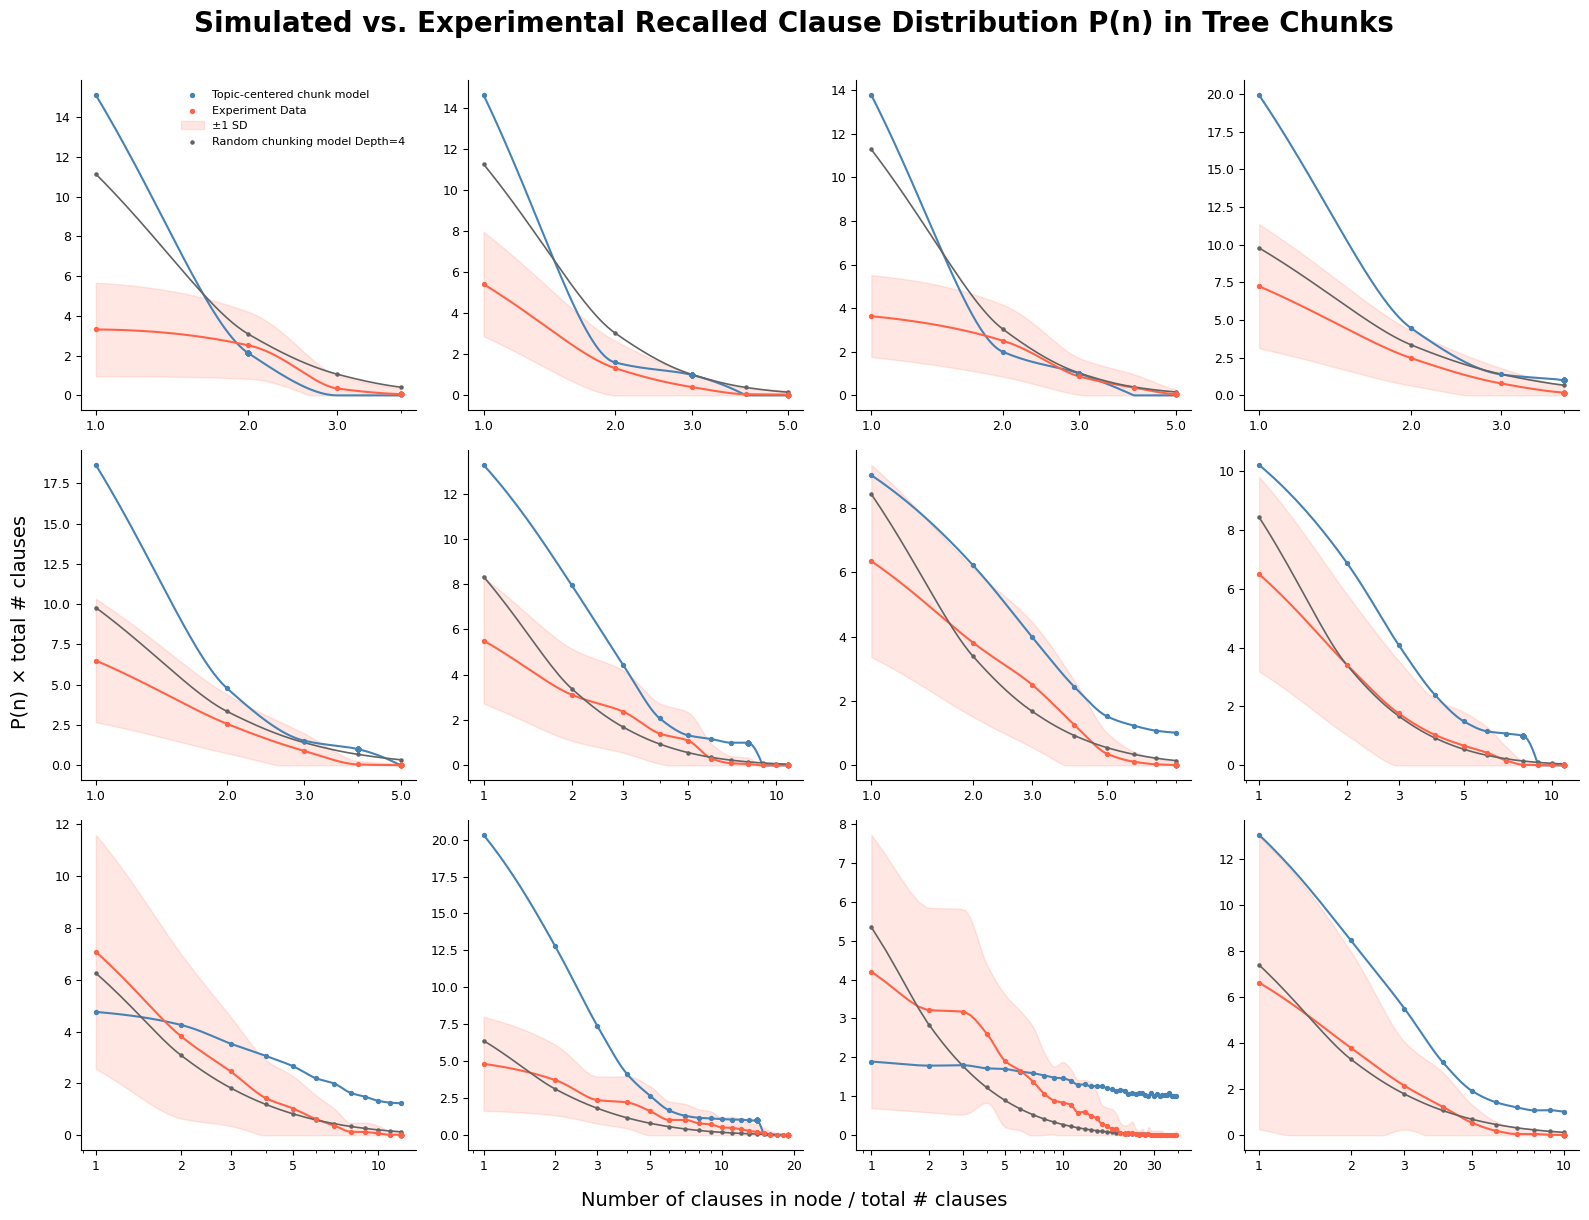

In [25]:
from scipy.interpolate import PchipInterpolator
import numpy as np
from matplotlib.ticker import LogLocator, LogFormatter

clauses = [19, 18, 18, 32, 32, 56, 54, 54, 130, 122, 194, 81]

def remove_trailing_repeats(lst, ylst):
    last_val = lst[-1]
    idx = len(lst) - 1
    while idx > 0 and lst[idx - 1] == last_val:
        idx -= 1
    return lst[:idx + 1], ylst[:idx + 1]

def pchip_smooth(x, y, x_out):
    fitx, fity = remove_trailing_repeats(list(x), list(y))
    # add a zero anchor beyond last point so curve decays smoothly
    step = (fitx[-1] - fitx[-2]) if len(fitx) > 1 else fitx[-1] * 0.1
    fitx = list(fitx) + [fitx[-1] + step]
    fity = list(fity) + [0.0]
    cs = PchipInterpolator(fitx, fity, extrapolate=False)
    y_out = np.array(cs(x_out), dtype=float)
    y_out = np.where(np.isnan(y_out) | (y_out < 0), 0, y_out)
    return y_out

##################################################################
simulated_data = y_padded;       simulated_x = x_padded
experiment_data = y_padded_experiment;  experiment_x = x_padded_experiment

simulated_fit_data = [];  fit_x = [];  experiment_fit_data = []
theoretical_layer2 = [];  theoretical_layer3 = []
std_data1 = [];           std_data2 = []

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()
fig.suptitle("Simulated vs. Experimental Recalled Clause Distribution P(n) in Tree Chunks",
             fontsize=20, fontweight='bold', y=1.01)

colors_theory = ['#bdbdbd', '#636363']   # light grey, dark grey

for i in np.arange(12):
    ax = axes[i]
    fit_max = np.max(experiment_x[i])   
    fit_min = max(np.min(experiment_x[i]), np.min(simulated_x[i]))
    x_smooth = np.linspace(fit_min, fit_max, 200)

    # ── Simulated ────────────────────────────────────────────────────────────
    y_sim = pchip_smooth(simulated_x[i], simulated_data[i], x_smooth)
    # ax.scatter(simulated_x[i], simulated_data[i], marker='o', color='steelblue', s=8, zorder=3,
    #            label='Simulated' if i == 0 else None)
    ax.plot(x_smooth, y_sim, '-', color='steelblue', lw=1.5)
    fit_x.append(x_smooth)
    simulated_fit_data.append(y_sim)
    mask_sim = np.array(simulated_x[i]) <= fit_max
    ax.scatter(np.array(simulated_x[i])[mask_sim], np.array(simulated_data[i])[mask_sim],
               marker='o', color='steelblue', s=8, zorder=3,
               label='Topic-centered chunk model' if i == 0 else None)
    
    # ── Experiment ───────────────────────────────────────────────────────────
    y_exp = pchip_smooth(experiment_x[i], experiment_data[i], x_smooth)
    y_std_hi = pchip_smooth(experiment_x[i], experiment_data[i] + std_padded_experiment[i], x_smooth)
    y_std_lo = pchip_smooth(experiment_x[i], experiment_data[i] - std_padded_experiment[i], x_smooth)

    ax.scatter(experiment_x[i], experiment_data[i], marker='o', color='tomato', s=8, zorder=3,
               label='Experiment Data' if i == 0 else None)
    ax.plot(x_smooth, y_exp, '-', color='tomato', lw=1.5)
    ax.fill_between(x_smooth, y_std_lo, y_std_hi, color='tomato', alpha=0.15,
                    label='±1 SD' if i == 0 else None)
    experiment_fit_data.append(y_exp)
    std_data1.append(y_std_hi)
    std_data2.append(y_std_lo)

    # ── Theoretical layers ───────────────────────────────────────────────────
    # Depth=3 removed, depth=4 is better.
    mask1 = np.array(x_all[i][0]) <= fit_max
    mask2 = np.array(x_all[i][1]) <= fit_max
    
    y2 = pchip_smooth(x_all[i][1], P_all[i][1][0], x_smooth)
    theoretical_layer3.append(y2)
    ax.scatter(np.array(x_all[i][1])[mask2], np.array(P_all[i][1][0])[mask2],
               marker='o', color=colors_theory[1], s=5, zorder=2,
               label='Random chunking model Depth=4' if i == 0 else None)
    ax.plot(x_smooth, y2, '-', color=colors_theory[1], lw=1.2)

   # ── Styling ───────────────────────────────────────────────────────────────
    from matplotlib.ticker import ScalarFormatter, AutoLocator
    ax.set_xscale('log')
    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.xaxis.set_major_locator(LogLocator(base=10, subs=[1, 2, 3, 5]))
    ax.xaxis.set_minor_formatter(plt.NullFormatter())
    ax.tick_params(labelsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    if i == 0:
        ax.legend(fontsize=8, frameon=False)

fig.supxlabel('Number of clauses in node / total # clauses', fontsize=14, y=0.01)
fig.supylabel('P(n) × total # clauses', fontsize=14, x=0.01)

plt.tight_layout()
plt.show()

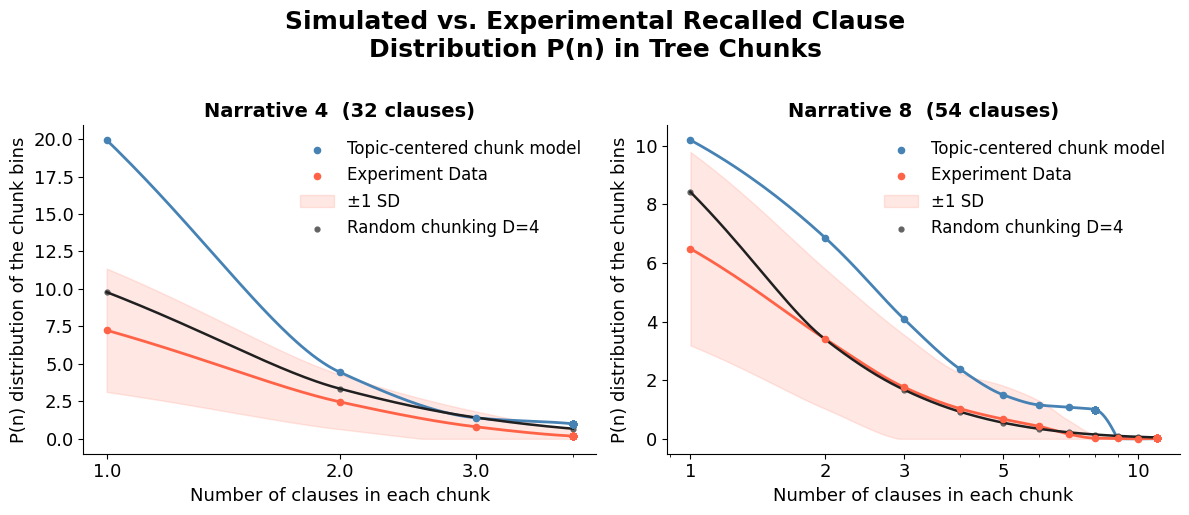

In [26]:
from matplotlib.ticker import LogLocator, ScalarFormatter

story_indices = [3, 7]  # narrative 4 and 8 (1-indexed)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Simulated vs. Experimental Recalled Clause\nDistribution P(n) in Tree Chunks",
             fontsize=18, fontweight='bold', y=1.02)

for ax, i in zip(axes, story_indices):
    fit_max  = np.max(experiment_x[i])
    fit_min  = max(np.min(experiment_x[i]), np.min(simulated_x[i]))
    x_smooth = np.linspace(fit_min, fit_max, 200)

    # ── Simulated ────────────────────────────────────────────────────────────
    y_sim = pchip_smooth(simulated_x[i], simulated_data[i], x_smooth)
    ax.plot(x_smooth, y_sim, '-', color='steelblue', lw=2.0)
    mask_sim = np.array(simulated_x[i]) <= fit_max
    ax.scatter(np.array(simulated_x[i])[mask_sim], np.array(simulated_data[i])[mask_sim],
               marker='o', color='steelblue', s=20, zorder=3,
               label='Topic-centered chunk model')

    # ── Experiment ───────────────────────────────────────────────────────────
    y_exp    = pchip_smooth(experiment_x[i], experiment_data[i], x_smooth)
    y_std_hi = pchip_smooth(experiment_x[i], experiment_data[i] + std_padded_experiment[i], x_smooth)
    y_std_lo = pchip_smooth(experiment_x[i], experiment_data[i] - std_padded_experiment[i], x_smooth)
    ax.scatter(experiment_x[i], experiment_data[i], marker='o', color='tomato', s=20, zorder=3,
               label='Experiment Data')
    ax.plot(x_smooth, y_exp, '-', color='tomato', lw=2.0)
    ax.fill_between(x_smooth, y_std_lo, y_std_hi, color='tomato', alpha=0.15, label='±1 SD')

    # ── Theoretical layers ───────────────────────────────────────────────────
    mask2 = np.array(x_all[i][1]) <= fit_max
    y2    = pchip_smooth(x_all[i][1], P_all[i][1][0], x_smooth)
    ax.scatter(np.array(x_all[i][1])[mask2], np.array(P_all[i][1][0])[mask2],
               marker='o', color=colors_theory[1], s=12, zorder=2, label='Random chunking D=4')
    ax.plot(x_smooth, y2, '-', color='#202020', lw=1.8)

    # ── Styling ───────────────────────────────────────────────────────────────
    ax.set_title(f'Narrative {i+1}  ({clauses[i]} clauses)', fontsize=14, fontweight='bold')
    ax.set_xscale('log')
    ax.xaxis.set_major_locator(LogLocator(base=10, subs=[1, 2, 3, 5]))
    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.xaxis.set_minor_formatter(plt.NullFormatter())
    ax.tick_params(labelsize=13)
    ax.set_xlabel('Number of clauses in each chunk', fontsize=13)
    ax.set_ylabel('P(n) distribution of the chunk bins', fontsize=13)
    ax.legend(fontsize=12, frameon=False)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


#### KL divergence, C value comparison between two tree models.

In [27]:
from scipy.stats import entropy

def KL_divergence(p, q):
    p = np.array(p, dtype=float)
    q = np.array(q, dtype=float)

    # normalize to sum to 1
    p = p / np.sum(p)
    q = q / np.sum(q)

    # add small epsilon to avoid log(0) or division by zero
    eps = 1e-10
    p = np.where(p <= 0, eps, p)
    q = np.where(q <= 0, eps, q)

    return entropy(p, q)   # scipy computes sum(p * log(p/q))

div_sim     = [KL_divergence(experiment_fit_data[i], simulated_fit_data[i])  for i in range(12)]
div_theory3 = [KL_divergence(experiment_fit_data[i], theoretical_layer3[i])  for i in range(12)]

print("Simulated:     ", [round(v, 4) for v in div_sim])
print("Theory layer3: ", [round(v, 4) for v in div_theory3])

Simulated:      [0.8571, 0.1845, 0.6442, 0.02, 0.0559, 0.0861, 0.1217, 0.076, 0.3259, 0.1822, 0.7317, 0.1217]
Theory layer3:  [0.0721, 0.0144, 0.0677, 0.012, 0.0581, 0.0793, 0.0578, 0.0296, 0.0363, 0.0887, 0.1114, 0.0555]


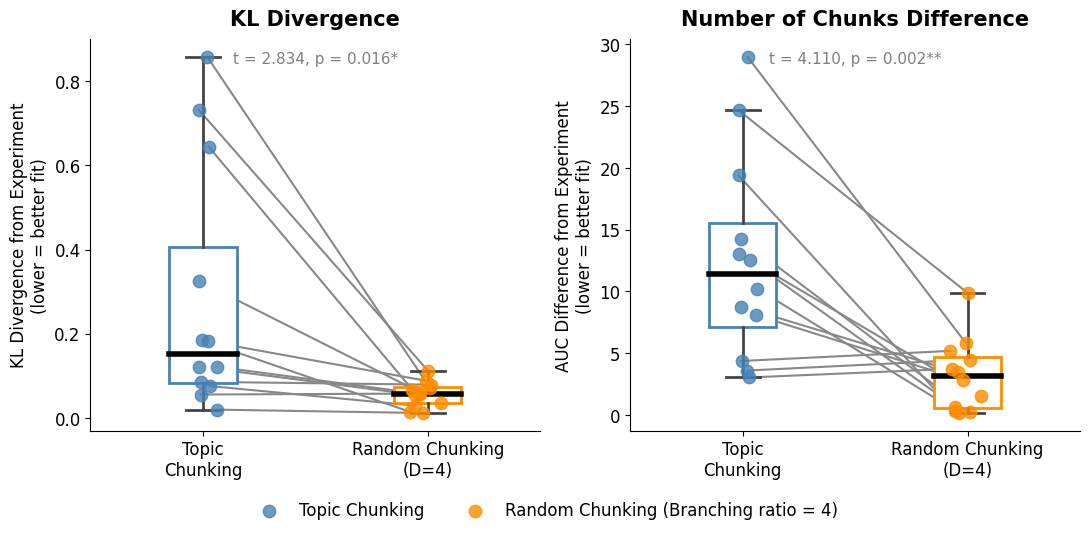

In [28]:
from scipy.stats import ttest_rel
import numpy as np
import matplotlib.pyplot as plt

# ── KL divergence ──
div_sim_kl     = [KL_divergence(experiment_fit_data[i], simulated_fit_data[i]) for i in range(12)]
div_theory3_kl = [KL_divergence(experiment_fit_data[i], theoretical_layer3[i]) for i in range(12)]
t_kl, p_kl = ttest_rel(div_sim_kl, div_theory3_kl)
p_label_kl  = f"p = {p_kl:.3f}*" if p_kl > 0.001 else "p < 0.001"

# ── AUC difference ──
auc_exp        = [np.trapz(experiment_fit_data[i], fit_x[i]) for i in range(12)]
auc_sim        = [np.trapz(simulated_fit_data[i],  fit_x[i]) for i in range(12)]
auc_theory3    = [np.trapz(theoretical_layer3[i],  fit_x[i]) for i in range(12)]
div_sim_auc     = [abs(auc_sim[i]     - auc_exp[i]) for i in range(12)]
div_theory3_auc = [abs(auc_theory3[i] - auc_exp[i]) for i in range(12)]
t_auc, p_auc = ttest_rel(div_sim_auc, div_theory3_auc)
p_label_auc  = f"p = {p_auc:.3f}**" if p_auc > 0.001 else "p < 0.001"

# ── shared jitter ──
np.random.seed(42)
jitter0 = np.random.normal(0, 0.04, 12)
jitter1 = np.random.normal(1, 0.04, 12)

def draw_panel(ax, data0, data1, ylabel, title, t_stat, p_label):
    bp = ax.boxplot([data0, data1], positions=[0, 1], widths=0.3,
                    patch_artist=True, showfliers=False,
                    boxprops=dict(facecolor='white', linewidth=2),
                    medianprops=dict(color='black', linewidth=4),
                    whiskerprops=dict(color='#444444', linewidth=2),
                    capprops=dict(color='#444444', linewidth=2))
    bp['boxes'][0].set_edgecolor('steelblue')
    bp['boxes'][1].set_edgecolor('darkorange')

    ax.scatter(jitter0, data0, color='steelblue',  s=80, zorder=3, alpha=0.8,
               label='Topic Chunking')
    ax.scatter(jitter1, data1, color='darkorange',  s=80, zorder=3, alpha=0.8,
               label='Random Chunking (Branching ratio = 4)')
    for i in range(12):
        ax.plot([jitter0[i], jitter1[i]], [data0[i], data1[i]],
                color='#888888', lw=1.5, zorder=1)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Topic\nChunking', 'Random Chunking\n(D=4)'], fontsize=13)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=15, fontweight='bold', pad=10)
    ax.tick_params(labelsize=12)
    ax.spines[['top', 'right']].set_visible(False)
    ax.text(0.5, 0.97, f"t = {t_stat:.3f}, {p_label}",
            ha='center', va='top', transform=ax.transAxes, fontsize=11, color='grey')

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

draw_panel(axes[0], div_sim_kl,  div_theory3_kl,
           "KL Divergence from Experiment\n(lower = better fit)",
           "KL Divergence", t_kl, p_label_kl)

draw_panel(axes[1], div_sim_auc, div_theory3_auc,
           "AUC Difference from Experiment\n(lower = better fit)",
           "Number of Chunks Difference", t_auc, p_label_auc)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, fontsize=12, frameon=False,
           loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.08))

plt.tight_layout()
plt.show()


In [79]:
n_topic = 12
k_topic = [len(curve_value_dic[i]) for i in range(n_topic)]

# ── compute smoothed curves ───────────────────────────────────────────────────
topic_fit_data2 = []
fit_x_topic     = []
theory3_topic   = []
exp_fit_topic   = []

for i in range(n_topic):
    fit_max  = np.max(experiment_x[i])
    fit_min  = max(np.min(experiment_x[i]), np.min(simulated_x[i]))
    x_smooth = np.linspace(fit_min, fit_max, 200)
    fit_x_topic.append(x_smooth)

    topic_fit_data2.append(pchip_smooth(simulated_x[i], simulated_data[i], x_smooth))
    theory3_topic.append(pchip_smooth(x_all[i][1], P_all[i][1][0], x_smooth))
    exp_fit_topic.append(pchip_smooth(experiment_x[i], experiment_data[i], x_smooth))

# ── per-story LL, AIC, BIC ────────────────────────────────────────────────────
results_topic = []
for i in range(n_topic):
    obs   = exp_fit_topic[i]
    n_obs = len(obs)

    ll_rand  = multinomial_loglik(obs, theory3_topic[i])
    ll_topic = multinomial_loglik(obs, topic_fit_data2[i])

    results_topic.append(dict(
        story      = i + 1,
        ll_random  = ll_rand,
        ll_topic   = ll_topic,
        aic_random = aic(ll_rand,  k_random),
        aic_topic  = aic(ll_topic, k_topic[i]),
        bic_random = bic(ll_rand,  k_random,    n_obs),
        bic_topic  = bic(ll_topic, k_topic[i],  n_obs),
    ))

# ── aggregate ─────────────────────────────────────────────────────────────────
total_ll_rand_t  = sum(r['ll_random'] for r in results_topic)
total_ll_topic   = sum(r['ll_topic']  for r in results_topic)
total_k_topic    = sum(k_topic)

total_aic_rand_t = aic(total_ll_rand_t, k_random)
total_aic_topic  = aic(total_ll_topic,  total_k_topic)
total_bic_rand_t = bic(total_ll_rand_t, k_random,     n_topic)
total_bic_topic  = bic(total_ll_topic,  total_k_topic, n_topic)

# ── report ────────────────────────────────────────────────────────────────────
print("=" * 75)
print("  Topic Chunking vs. Random Chunking (12 stories)")
print("=" * 75)
print(f"  {'Story':>5}  {'LL_rand':>9}  {'LL_topic':>9}  "
      f"{'AIC_rand':>9}  {'AIC_topic':>9}  {'BIC_rand':>9}  {'BIC_topic':>9}")
print("=" * 75)
for r in results_topic:
    better = '<' if r['ll_topic'] > r['ll_random'] else '>'
    print(f"  {r['story']:>5}  {r['ll_random']:>9.2f}  {r['ll_topic']:>9.2f}  "
          f"{r['aic_random']:>9.2f}  {r['aic_topic']:>9.2f}  "
          f"{r['bic_random']:>9.2f}  {r['bic_topic']:>9.2f}  {better}")
print("=" * 75)
print(f"  Total  {total_ll_rand_t:>9.2f}  {total_ll_topic:>9.2f}  "
      f"{total_aic_rand_t:>9.2f}  {total_aic_topic:>9.2f}  "
      f"{total_bic_rand_t:>9.2f}  {total_bic_topic:>9.2f}")
print("=" * 75)
print(f"\n  ΔAIC (topic − random) = {total_aic_topic - total_aic_rand_t:.2f}")
print(f"  ΔBIC (topic − random) = {total_bic_topic - total_bic_rand_t:.2f}")
print(f"  (negative = topic is better; >10 = strong evidence)")


  Topic Chunking vs. Random Chunking (12 stories)
  Story    LL_rand   LL_topic   AIC_rand  AIC_topic   BIC_rand  BIC_topic
      1   -1513.43   -1823.79    3026.85    3651.57    3026.85    3658.17  >
      2    -935.64    -984.17    1871.29    1974.33    1871.29    1984.23  >
      3   -1376.00   -1588.93    2752.00    3183.86    2752.00    3193.76  >
      4   -2133.43   -2136.90    4266.86    4281.80    4266.86    4294.99  >
      5   -1508.48   -1507.84    3016.96    3023.67    3016.96    3036.87  <
      6   -1014.88   -1017.03    2029.76    2050.05    2029.76    2076.44  >
      7   -1486.24   -1506.42    2972.48    3032.83    2972.48    3065.81  >
      8    -942.84    -953.74    1885.68    1923.48    1885.68    1949.87  >
      9   -1122.44   -1193.14    2244.89    2448.29    2244.89    2550.54  >
     10    -974.70   -1003.76    1949.39    2035.52    1949.39    2081.69  >
     11    -538.00    -613.50    1076.01    1327.00    1076.01    1491.92  >
     12   -1127.27   -1143.73

In [29]:
from scipy.stats import ttest_rel, t as sp_t
import numpy as np

n_perm = 10000
n_boot = 10000

def paired_stats(a, b, label):
    a    = np.array(a, dtype=float)
    b    = np.array(b, dtype=float)
    diff = a - b
    n    = len(diff)
    dfc  = n - 1

    t_stat, p_val = ttest_rel(a, b)
    mean_diff = np.mean(diff)
    std_diff  = np.std(diff, ddof=1)
    se_diff   = std_diff / np.sqrt(n)
    cohen_d   = mean_diff / std_diff
    t_crit    = sp_t.ppf(0.975, dfc)
    ci_diff   = [mean_diff - t_crit * se_diff,
                 mean_diff + t_crit * se_diff]
    power     = (1 - sp_t.cdf(t_crit,  dfc, loc=abs(t_stat))
                   + sp_t.cdf(-t_crit, dfc, loc=abs(t_stat)))

    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"{'='*60}")
    print("  PARAMETRIC PAIRED T-TEST")
    print(f"  n              = {n}")
    print(f"  mean diff      = {mean_diff:.4f}  CI=[{ci_diff[0]:.4f}, {ci_diff[1]:.4f}]")
    print(f"  mean (a)       = {np.mean(a):.4f}  ± {np.std(a, ddof=1):.4f}")
    print(f"  mean (b)       = {np.mean(b):.4f}  ± {np.std(b, ddof=1):.4f}")

    print(f"  std diff       = {std_diff:.4f}")
    print(f"  t({dfc})        = {t_stat:.4f}")
    print(f"  p              = {p_val:.4e}")
    print(f"  Cohen's d      = {cohen_d:.4f}  ({'small' if abs(cohen_d)<0.5 else 'medium' if abs(cohen_d)<0.8 else 'large'})")
    print(f"  Power          = {power:.4f}")

    # ── permutation ──
    rng_p  = np.random.default_rng(0)
    t_null = []
    for _ in range(n_perm):
        signs  = rng_p.choice([-1, 1], size=n)
        dp     = diff * signs
        t_null.append(np.mean(dp) / (np.std(dp, ddof=1) / np.sqrt(n)))
    t_null = np.array(t_null)
    p_perm = np.mean(np.abs(t_null) >= np.abs(t_stat))

    print(f"\n  PERMUTATION  (n={n_perm})")
    print(f"  t_obs          = {t_stat:.4f}")
    print(f"  p_perm         = {p_perm:.4f}")
    print(f"  null: mean={t_null.mean():.4f}, std={t_null.std():.4f}, "
          f"95th={np.percentile(np.abs(t_null), 95):.4f}")

    # ── bootstrap ──
    rng_b = np.random.default_rng(1)
    mean_b, d_b, t_b = [], [], []
    for _ in range(n_boot):
        idx = rng_b.choice(n, n, replace=True)
        db  = diff[idx]
        mb  = np.mean(db)
        sb  = np.std(db, ddof=1)
        mean_b.append(mb)
        d_b.append(mb / sb)
        t_b.append(mb / (sb / np.sqrt(n)))

    mean_b = np.array(mean_b)
    d_b    = np.array(d_b)
    t_b    = np.array(t_b)
    p_boot   = 2 * min(np.mean(mean_b <= 0), np.mean(mean_b >= 0))
    pow_boot = np.mean(np.abs(t_b) >= t_crit)

    print(f"\n  BOOTSTRAP  (n={n_boot})")
    print(f"  p              = {p_boot:.4f}")
    print(f"  mean diff      = {np.mean(mean_b):.4f}  CI=[{np.percentile(mean_b,2.5):.4f}, {np.percentile(mean_b,97.5):.4f}]")
    print(f"  mean (a)       = {np.mean(a):.4f}  ± {np.std(a, ddof=1):.4f}")
    print(f"  mean (b)       = {np.mean(b):.4f}  ± {np.std(b, ddof=1):.4f}")
    print(f"  Cohen's d      = {np.mean(d_b):.4f}  CI=[{np.percentile(d_b,2.5):.4f}, {np.percentile(d_b,97.5):.4f}]")
    print(f"  Power          = {pow_boot:.4f}")

paired_stats(div_sim_kl,  div_theory3_kl,  "KL DIVERGENCE  (Topic vs Random D=4)")
paired_stats(div_sim_auc, div_theory3_auc, "AUC DIFFERENCE  (Topic vs Random D=4)")



  KL DIVERGENCE  (Topic vs Random D=4)
  PARAMETRIC PAIRED T-TEST
  n              = 12
  mean diff      = 0.2270  CI=[0.0507, 0.4033]
  mean (a)       = 0.2839  ± 0.2919
  mean (b)       = 0.0569  ± 0.0299
  std diff       = 0.2775
  t(11)        = 2.8336
  p              = 1.6268e-02
  Cohen's d      = 0.8180  (large)
  Power          = 0.7302

  PERMUTATION  (n=10000)
  t_obs          = 2.8336
  p_perm         = 0.0004
  null: mean=-0.0018, std=1.0811, 95th=2.2508

  BOOTSTRAP  (n=10000)
  p              = 0.0000
  mean diff      = 0.2259  CI=[0.0872, 0.3859]
  mean (a)       = 0.2839  ± 0.2919
  mean (b)       = 0.0569  ± 0.0299
  Cohen's d      = 0.8632  CI=[0.5555, 1.2897]
  Power          = 0.9123

  AUC DIFFERENCE  (Topic vs Random D=4)
  PARAMETRIC PAIRED T-TEST
  n              = 12
  mean diff      = 9.4036  CI=[4.3676, 14.4396]
  mean (a)       = 12.5853  ± 8.2262
  mean (b)       = 3.1817  ± 2.9089
  std diff       = 7.9261
  t(11)        = 4.1098
  p              = 1.730

### Manual annotation of chunks to compare with LLM chunking result on experiment data.

In [30]:
for i, item in enumerate(story_processed_all[3], start=1):
    print(f"{i}: {item}")

1:  Back in the days when I was a rookie in the police force, the Chief was a veteran.
2:  He had caught a notorious criminal –
3:  or had been awarded for bravery.
4:  But he had – a young daughter.
5:  And in those days I was a fitness enthusiast.
6:  And it seemed she was trying to impress me.
7:  I never observed it.
8:  Truth is I wasn't very fond of her because she was –
9:  She was a charming girl until she opened her mouth.
10:  She was a chatterbox.
11:  Goodness, she could talk.
12:  Then she left a message one day saying she was going to run away because he was always scolding her about me.
13:  He arrived at my apartment.
14:  Big intimidating look on his face.
15:  I managed to calm him down.
16:  and proposed “Well we'll search for her
17:  and if we can't locate her well you can – do whatever you think is right.”
18:  I was strategizing.
19:  So he accepted my offer.
20:  And we went to where they found her scarf – near a park.
21:  and we traced down a little more
22:  

In [31]:
for i, item in enumerate(recall_processed_all[3][10], start=1):
    print(f"{i}: {item}")

1:  The narrator is a rookie police man.
2:  The daughter of the Chief likes him 
3:  but runs away 
4:  as her father is always scolding her. 
5:  He then goes looking for her 
6:  but find her reading a book in the police station. 
7:  He is then told 
8:  that he had better leave the police.


In [39]:
chunking_data = []
chunking_data.append([[1], [4,6], [12], [13], [16, 20], [24,25], [28], [28], [29,30,31]])  # some summarization. one original sentence recalled twice.
chunking_data.append([[4], [6], [7], [8], [10], [12], [24, 25], [25], [30]])   # quite selective. one original sentence recalled twice.
chunking_data.append([[1], [1], [3], [4], [5,6], [12], [18], [16], [20], [24], [24, 25], [28], [28], [29, 31], [32]])  # tried to recall each clause by clause, then a large part of details cut. combine some loose sentences together into one.
chunking_data.append([[1, 4], [5, 6], [12], [12], [13, 16], [20], [24, 25], [26], [28], [29, 30]])  # combine loose sentences together, ignored largely some detailed clauses in the middle.
chunking_data.append([[1], [1], [4], [5], [6], [11], [12], [12], [13, 14], [15], [16], [20], [20], [24], [25], [26], [28], [28], [29, 30], [32]])  ## this person did not summarize much, mostly clause by clause. and recalled clauses others ignored.
chunking_data.append([[1], [1], [1], [2], [4], [5, 6], [7], [8, 10], [12], [13, 14], [16], [18], [20], [24, 25], [26, 27], [28], [29], [30], [32]])
chunking_data.append([[1], [1], [2,3], [5], [6], [8], [9], [10], [12], [16], [17], [17], [20], [21, 22], [23, 24], [25], [28], [30], [32]])  # people say one long clause in the narrative with 2-3 clauses.
chunking_data.append([[1], [1], [2], [5], [4, 9, 10], [12], [16], [23,24], [25], [28], [32]])
chunking_data.append([[1], [1, 4], [8], [9], [12], [13], [16], [18], [20], [24, 25], [26], [28], [28], [29, 30], [32]])
chunking_data.append([[1], [1, 4], [6], [10], [12], [23, 24], [25], [26], [28], [32]])  # people really memorize different parts of the story and details.
chunking_data.append([[1],[1,4,6], [12], [12], [16], [24, 25], [28]])  # this person summarizes.
chunking_data.append([[1], [1], [4,6], [6], [8], [10], [12], [12], [13], [16], [20,21,22], [20], [23, 24], [25], [26], [28], [28], [29,30]])  # summarization "searching", combine multiple sentences together. extraction is a stong part in people's recall still, abstraction can be at different levels.
chunking_data.append([[1], [4, 6], [12], [12], [16], [26], [30]])  # not really much chunking.
chunking_data.append([[1], [1,2], [5], [4, 6], [12], [13], [14], [18], [16], [17], [21,22], [20,24,25], [26], [28], [28], [29], [30], [32]])
chunking_data.append([[1,2,3], [4], [9], [9], [9], [9], [10], [11], [10], [12], [12], [13], [16], [17], [17], [20], [22], [23, 24], [25], [28], [28], [30], [32]])

print(chunking_data)

[[[1], [4, 6], [12], [13], [16, 20], [24, 25], [28], [28], [29, 30, 31]], [[4], [6], [7], [8], [10], [12], [24, 25], [25], [30]], [[1], [1], [3], [4], [5, 6], [12], [18], [16], [20], [24], [24, 25], [28], [28], [29, 31], [32]], [[1, 4], [5, 6], [12], [12], [13, 16], [20], [24, 25], [26], [28], [29, 30]], [[1], [1], [4], [5], [6], [11], [12], [12], [13, 14], [15], [16], [20], [20], [24], [25], [26], [28], [28], [29, 30], [32]], [[1], [1], [1], [2], [4], [5, 6], [7], [8, 10], [12], [13, 14], [16], [18], [20], [24, 25], [26, 27], [28], [29], [30], [32]], [[1], [1], [2, 3], [5], [6], [8], [9], [10], [12], [16], [17], [17], [20], [21, 22], [23, 24], [25], [28], [30], [32]], [[1], [1], [2], [5], [4, 9, 10], [12], [16], [23, 24], [25], [28], [32]], [[1], [1, 4], [8], [9], [12], [13], [16], [18], [20], [24, 25], [26], [28], [28], [29, 30], [32]], [[1], [1, 4], [6], [10], [12], [23, 24], [25], [26], [28], [32]], [[1], [1, 4, 6], [12], [12], [16], [24, 25], [28]], [[1], [1], [4, 6], [6], [8], [1

In [40]:
from collections import Counter
import numpy as np

# ── per-participant chunk-size distributions ──────────────────────────────────
prob_dicts_chunking = []
for participant in chunking_data:
    sizes  = [len(chunk) for chunk in participant]
    counts = Counter(sizes)
    prob_dicts_chunking.append(counts)

# ── fill missing keys and average across participants ─────────────────────────
max_key     = max(k for d in prob_dicts_chunking for k in d)
all_keys    = np.arange(1, max_key + 1)
values_list = [[d.get(k, 0) for k in all_keys] for d in prob_dicts_chunking]

mean_values = np.mean(values_list, axis=0)
std_values  = np.std( values_list, axis=0)

mean_dict_chunking = {k: v for k, v in zip(all_keys, mean_values)}
std_dict_chunking  = {k: v for k, v in zip(all_keys, std_values)}

# ── extract as arrays ─────────────────────────────────────────────────────────
x_chunking   = np.array(sorted(mean_dict_chunking.keys()))
y_chunking   = np.array([mean_dict_chunking[k] for k in x_chunking])
std_chunking = np.array([std_dict_chunking[k]  for k in x_chunking])

print("chunk sizes (x):", x_chunking)
print("mean counts (y):", y_chunking.round(3))
print("std  counts    :", std_chunking.round(3))


chunk sizes (x): [1 2 3]
mean counts (y): [11.133  2.467  0.4  ]
std  counts    : [4.884 1.31  0.49 ]


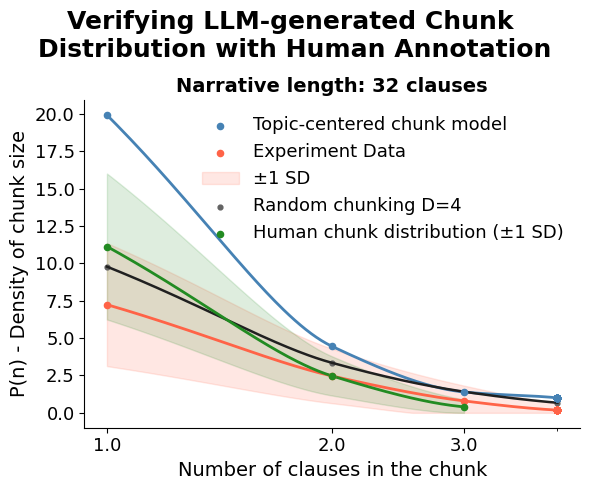

In [53]:
## put the manual chunking data into the curve.
from collections import Counter

i = 3  # story index.

participant_distributions = []
for participant in chunking_data:
    sizes_p = [len(chunk) for chunk in participant]
    participant_distributions.append(Counter(sizes_p))

max_size = max(s for d in participant_distributions for s in d)
size_range = range(1, max_size + 1)
avg_counts = np.array([np.mean([d.get(s, 0) for d in participant_distributions]) for s in size_range])
std_counts  = np.array([np.std( [d.get(s, 0) for d in participant_distributions]) for s in size_range])

fig, ax = plt.subplots(figsize=(6, 5))

fit_max = np.max(experiment_x[i])
fit_min = max(np.min(experiment_x[i]), np.min(simulated_x[i]))
x_smooth = np.linspace(fit_min, fit_max, 200)

# ── Simulated ────────────────────────────────────────────────────────────────
y_sim = pchip_smooth(simulated_x[i], simulated_data[i], x_smooth)
ax.plot(x_smooth, y_sim, '-', color='steelblue', lw=2.0)
mask_sim = np.array(simulated_x[i]) <= fit_max
ax.scatter(np.array(simulated_x[i])[mask_sim], np.array(simulated_data[i])[mask_sim],
           marker='o', color='steelblue', s=20, zorder=3,
           label='Topic-centered chunk model')

# ── Experiment ───────────────────────────────────────────────────────────────
y_exp    = pchip_smooth(experiment_x[i], experiment_data[i], x_smooth)
y_std_hi = pchip_smooth(experiment_x[i], experiment_data[i] + std_padded_experiment[i], x_smooth)
y_std_lo = pchip_smooth(experiment_x[i], experiment_data[i] - std_padded_experiment[i], x_smooth)
ax.scatter(experiment_x[i], experiment_data[i], marker='o', color='tomato', s=20, zorder=3,
           label='Experiment Data')
ax.plot(x_smooth, y_exp, '-', color='tomato', lw=2.0)
ax.fill_between(x_smooth, y_std_lo, y_std_hi, color='tomato', alpha=0.15, label='±1 SD')

# ── Theoretical layers ────────────────────────────────────────────────────────
mask1 = np.array(x_all[i][0]) <= fit_max
mask2 = np.array(x_all[i][1]) <= fit_max
y2 = pchip_smooth(x_all[i][1], P_all[i][1][0], x_smooth)
ax.scatter(np.array(x_all[i][1])[mask2], np.array(P_all[i][1][0])[mask2],
           marker='o', color=colors_theory[1], s=12, zorder=2, label='Random chunking D=4')
ax.plot(x_smooth, y2, '-', color='#202020', lw=1.8)   # near black

# ── Human chunk distribution ──────────────────────────────────────────────────
participant_distributions = []
for participant in chunking_data:          # ← filter by story i
    sizes_p = [len(chunk) for chunk in participant]
    participant_distributions.append(Counter(sizes_p))

max_size   = max(s for d in participant_distributions for s in d)
size_range = range(1, max_size + 1)
avg_counts = np.array([np.mean([d.get(s, 0) for d in participant_distributions]) for s in size_range])
std_counts = np.array([np.std( [d.get(s, 0) for d in participant_distributions]) for s in size_range])

chunk_x = np.array(list(size_range))
mask_c  = avg_counts > 0

if mask_c.sum() >= 2:
    x_cs    = np.linspace(chunk_x[mask_c].min(), min(chunk_x[mask_c].max(), fit_max), 200)  # ← cap at fit_max
    y_cs    = pchip_smooth(chunk_x[mask_c], avg_counts[mask_c],                        x_cs)
    y_cs_hi = pchip_smooth(chunk_x[mask_c], (avg_counts + std_counts)[mask_c],         x_cs)
    y_cs_lo = pchip_smooth(chunk_x[mask_c], np.maximum(avg_counts - std_counts, 0)[mask_c], x_cs)
    ax.plot(x_cs, y_cs, '-', color='forestgreen', lw=2.0)
    ax.fill_between(x_cs, y_cs_lo, y_cs_hi, color='forestgreen', alpha=0.15)

ax.scatter(chunk_x[mask_c], avg_counts[mask_c],
           marker='o', color='forestgreen', s=20, zorder=3,
           label='Human chunk distribution (±1 SD)')


# ── Styling ───────────────────────────────────────────────────────────────────
fig.suptitle("Verifying LLM-generated Chunk \nDistribution with Human Annotation",
             fontsize=18, fontweight='bold', y=0.97)
ax.set_title(f'Narrative length: {clauses[i]} clauses', fontsize=14, fontweight='bold')
from matplotlib.ticker import ScalarFormatter
ax.set_xscale('log')
ax.xaxis.set_major_locator(LogLocator(base=10, subs=[1, 2, 3, 5]))
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.xaxis.set_minor_formatter(plt.NullFormatter())
ax.tick_params(labelsize=13)
ax.set_xlabel('Number of clauses in the chunk', fontsize=14)
ax.set_ylabel('P(n) - Density of chunk size', fontsize=14)
ax.legend(fontsize=13, frameon=False)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

### Event segmentation chunking test.

### All situational change cues.

In [61]:
## boundary segmentation with all situational change cues.
boundary_segmentation = [
    [1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 3, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 3, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1],
    [1, 3, 1, 1, 2, 4, 1, 2, 1, 1, 2, 1, 2, 3, 1, 1, 1, 4],
    [1, 3, 1, 1, 2, 4, 1, 2, 1, 1, 2, 1, 2, 3, 1, 1, 1, 4],
    [1, 1, 4, 1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 3, 1, 1],
    [1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 3, 1, 1, 3, 2, 1, 2, 3, 3, 2, 2, 1, 4, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 2, 2, 2, 1, 1, 2, 1, 1, 1, 1, 2, 2, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 4, 1, 1, 3, 1, 1, 1, 1, 1, 2, 2, 2, 2, 1, 1, 2, 2, 3, 1, 2, 1, 3, 1, 1, 2, 1, 1, 2, 3, 2, 3, 1, 4, 2, 3, 1, 2, 1, 2, 1, 1, 1, 2, 1, 1, 2, 2, 2, 2, 3, 1, 1, 5, 3, 2, 1, 1, 1, 3, 1, 3, 1, 1, 3, 2, 2, 2, 1, 2, 1, 2, 1, 1],
]

In [62]:
avg_dict_all_boundary = []

for story_number in range(9):
    initial_clause = boundary_segmentation[story_number]

    sim_recall_layer = []
    for i in np.arange(sim_times):
        sim_next_branch = generate_branch_random(initial_clause, 2)
        sim_recall_layer.append(sim_next_branch)

        if i % 100 == 99:
            print(f"Story {story_number+1} — simulation {i+1} done")

    prob_data_all = []
    for layer in sim_recall_layer:
        layer_data = np.array(layer).flatten()
        unique, counts = np.unique(layer_data, return_counts=True)
        prob_dict = {int(val): count for val, count in zip(unique, counts) if val != 0}
        prob_data_all.append(prob_dict)

    values = defaultdict(list)
    for d in prob_data_all:
        for k, v in d.items():
            values[k].append(v)

    avg_dict = {k: np.mean(vs) for k, vs in values.items()}
    avg_dict_all_boundary.append(avg_dict)
    print(f"Story {story_number+1}: avg_dict = {avg_dict}")

print(f"\nDone. avg_dict_all_boundary has {len(avg_dict_all_boundary)} entries.")


Story 1 — simulation 100 done
Story 1 — simulation 200 done
Story 1 — simulation 300 done
Story 1 — simulation 400 done
Story 1 — simulation 500 done
Story 1: avg_dict = {1: 17.368, 2: 1.2439024390243902}
Story 2 — simulation 100 done
Story 2 — simulation 200 done
Story 2 — simulation 300 done
Story 2 — simulation 400 done
Story 2 — simulation 500 done
Story 2: avg_dict = {1: 15.444, 2: 1.3159268929503916, 3: 1.0}
Story 3 — simulation 100 done
Story 3 — simulation 200 done
Story 3 — simulation 300 done
Story 3 — simulation 400 done
Story 3 — simulation 500 done
Story 3: avg_dict = {1: 15.47, 2: 1.304945054945055, 3: 1.0}
Story 4 — simulation 100 done
Story 4 — simulation 200 done
Story 4 — simulation 300 done
Story 4 — simulation 400 done
Story 4 — simulation 500 done
Story 4: avg_dict = {1: 19.57, 2: 4.046184738955823, 3: 1.5564971751412429, 4: 1.0555555555555556}
Story 5 — simulation 100 done
Story 5 — simulation 200 done
Story 5 — simulation 300 done
Story 5 — simulation 400 done
St

In [63]:
# ── preparation (same pipeline as avg_dict_all) ───────────────────────────────
curve_value_raw_boundary = [
    [hist[k] for k in sorted(hist.keys())]
    for hist in avg_dict_all_boundary
]

curve_value_histo_boundary = [[item for item in data] for data in curve_value_raw_boundary]

x_value_scaled_boundary = [
    [item for item in np.arange(1, len(data)+1)]
    for data in curve_value_histo_boundary
]

max_len_b         = max(len(s) for s in curve_value_histo_boundary)
y_padded_boundary = np.array([
    s + [s[-1]] * (max_len_b - len(s)) for s in curve_value_histo_boundary
])

x_padded_boundary = []
for sublist in x_value_scaled_boundary:
    current_len = len(sublist)
    if current_len < max_len_b:
        extension = sublist[-1] + 0 * np.arange(1, max_len_b - current_len + 1)
        x_padded_boundary.append(np.concatenate([sublist, extension]))
    else:
        x_padded_boundary.append(np.array(sublist))
x_padded_boundary = np.array(x_padded_boundary)



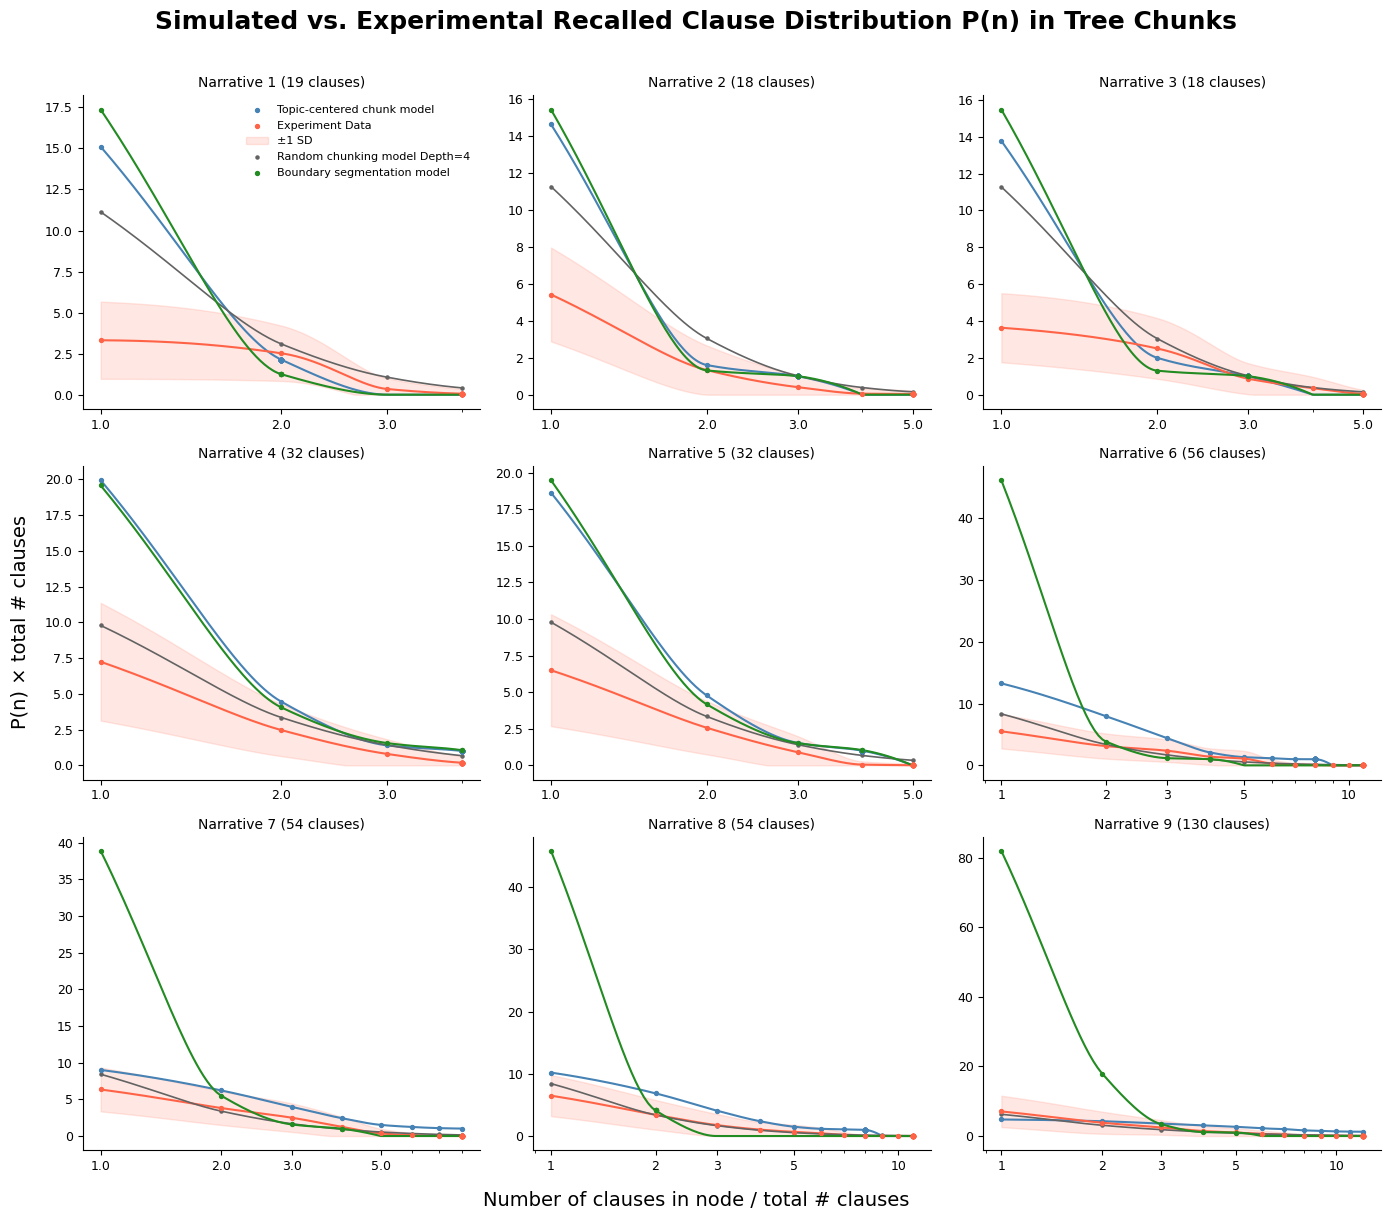

In [74]:
# ── plot (add boundary curve into existing loop) ──────────────────────────────
n_boundary      = len(avg_dict_all_boundary)   # 9
simulated_data  = y_padded;          simulated_x  = x_padded
experiment_data = y_padded_experiment; experiment_x = x_padded_experiment
colors_theory   = ['#bdbdbd', '#636363']

simulated_fit_data = []; fit_x = []; experiment_fit_data = []
theoretical_layer3 = []; std_data1 = []; std_data2 = []

fig, axes = plt.subplots(3, 3, figsize=(14, 12))
axes = axes.flatten()
fig.suptitle("Simulated vs. Experimental Recalled Clause Distribution P(n) in Tree Chunks",
             fontsize=18, fontweight='bold', y=1.01)

for i in range(9):
    ax = axes[i]
    fit_max  = np.max(experiment_x[i])
    fit_min  = max(np.min(experiment_x[i]), np.min(simulated_x[i]))
    x_smooth = np.linspace(fit_min, fit_max, 200)

    # ── Simulated ─────────────────────────────────────────────────────────────
    y_sim = pchip_smooth(simulated_x[i], simulated_data[i], x_smooth)
    ax.plot(x_smooth, y_sim, '-', color='steelblue', lw=1.5)
    fit_x.append(x_smooth); simulated_fit_data.append(y_sim)
    mask_sim = np.array(simulated_x[i]) <= fit_max
    ax.scatter(np.array(simulated_x[i])[mask_sim], np.array(simulated_data[i])[mask_sim],
               marker='o', color='steelblue', s=8, zorder=3,
               label='Topic-centered chunk model' if i == 0 else None)

    # ── Experiment ────────────────────────────────────────────────────────────
    y_exp    = pchip_smooth(experiment_x[i], experiment_data[i], x_smooth)
    y_std_hi = pchip_smooth(experiment_x[i], experiment_data[i] + std_padded_experiment[i], x_smooth)
    y_std_lo = pchip_smooth(experiment_x[i], experiment_data[i] - std_padded_experiment[i], x_smooth)
    ax.scatter(experiment_x[i], experiment_data[i], marker='o', color='tomato', s=8, zorder=3,
               label='Experiment Data' if i == 0 else None)
    ax.plot(x_smooth, y_exp, '-', color='tomato', lw=1.5)
    ax.fill_between(x_smooth, y_std_lo, y_std_hi, color='tomato', alpha=0.15,
                    label='±1 SD' if i == 0 else None)
    experiment_fit_data.append(y_exp); std_data1.append(y_std_hi); std_data2.append(y_std_lo)

    # ── Theoretical layers ────────────────────────────────────────────────────
    mask2 = np.array(x_all[i][1]) <= fit_max
    y2    = pchip_smooth(x_all[i][1], P_all[i][1][0], x_smooth)
    theoretical_layer3.append(y2)
    ax.scatter(np.array(x_all[i][1])[mask2], np.array(P_all[i][1][0])[mask2],
               marker='o', color=colors_theory[1], s=5, zorder=2,
               label='Random chunking model Depth=4' if i == 0 else None)
    ax.plot(x_smooth, y2, '-', color=colors_theory[1], lw=1.2)

    # ── Boundary ──────────────────────────────────────────────────────────────
    if i < n_boundary:
        y_b = pchip_smooth(x_padded_boundary[i], y_padded_boundary[i], x_smooth)
        mask_b = np.array(x_padded_boundary[i]) <= fit_max
        ax.plot(x_smooth, y_b, '-', color='forestgreen', lw=1.5)
        ax.scatter(np.array(x_padded_boundary[i])[mask_b],
                   np.array(y_padded_boundary[i])[mask_b],
                   marker='o', color='forestgreen', s=8, zorder=3,
                   label='Boundary segmentation model' if i == 0 else None)

    # ── Styling ───────────────────────────────────────────────────────────────
    ax.set_xscale('log')
    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.xaxis.set_major_locator(LogLocator(base=10, subs=[1, 2, 3, 5]))
    ax.xaxis.set_minor_formatter(plt.NullFormatter())
    ax.tick_params(labelsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_title(f"Narrative {i+1} ({clauses[i]} clauses)", fontsize=10)
    if i == 0:
        ax.legend(fontsize=8, frameon=False)

fig.supxlabel('Number of clauses in node', fontsize=14, y=0.01)
fig.supylabel('P(n)', fontsize=14, x=0.01)
plt.tight_layout()
plt.show()


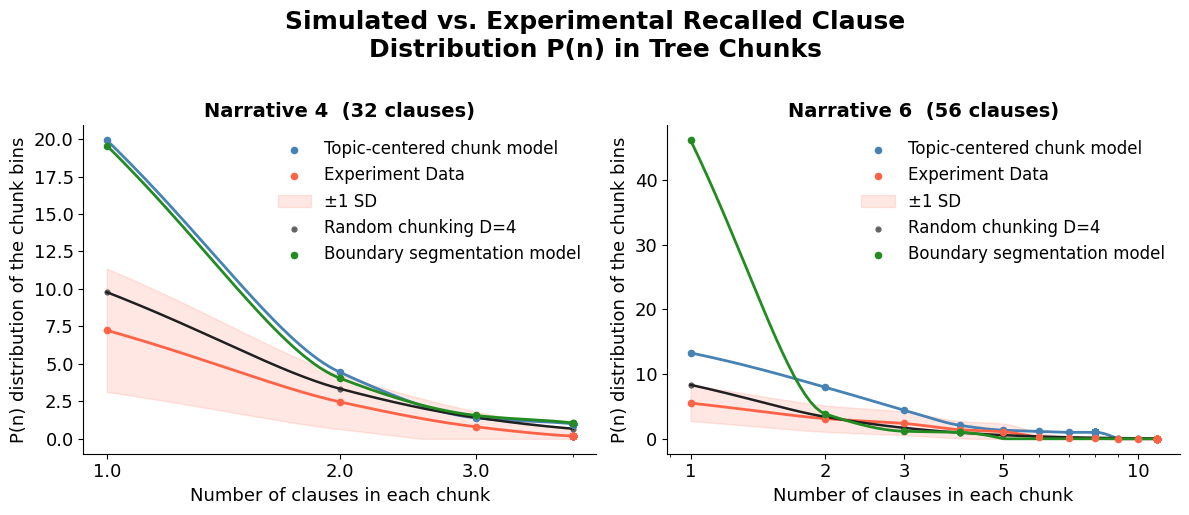

In [75]:
from matplotlib.ticker import LogLocator, ScalarFormatter

story_indices = [3, 5]  # narrative 4 and 6 (0-indexed)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Simulated vs. Experimental Recalled Clause\nDistribution P(n) in Tree Chunks",
             fontsize=18, fontweight='bold', y=1.02)

for ax, i in zip(axes, story_indices):
    fit_max  = np.max(experiment_x[i])
    fit_min  = max(np.min(experiment_x[i]), np.min(simulated_x[i]))
    x_smooth = np.linspace(fit_min, fit_max, 200)

    # ── Simulated ────────────────────────────────────────────────────────────
    y_sim = pchip_smooth(simulated_x[i], simulated_data[i], x_smooth)
    ax.plot(x_smooth, y_sim, '-', color='steelblue', lw=2.0)
    mask_sim = np.array(simulated_x[i]) <= fit_max
    ax.scatter(np.array(simulated_x[i])[mask_sim], np.array(simulated_data[i])[mask_sim],
               marker='o', color='steelblue', s=20, zorder=3,
               label='Topic-centered chunk model')

    # ── Experiment ───────────────────────────────────────────────────────────
    y_exp    = pchip_smooth(experiment_x[i], experiment_data[i], x_smooth)
    y_std_hi = pchip_smooth(experiment_x[i], experiment_data[i] + std_padded_experiment[i], x_smooth)
    y_std_lo = pchip_smooth(experiment_x[i], experiment_data[i] - std_padded_experiment[i], x_smooth)
    ax.scatter(experiment_x[i], experiment_data[i], marker='o', color='tomato', s=20, zorder=3,
               label='Experiment Data')
    ax.plot(x_smooth, y_exp, '-', color='tomato', lw=2.0)
    ax.fill_between(x_smooth, y_std_lo, y_std_hi, color='tomato', alpha=0.15, label='±1 SD')

    # ── Theoretical layers ────────────────────────────────────────────────────
    mask2 = np.array(x_all[i][1]) <= fit_max
    y2    = pchip_smooth(x_all[i][1], P_all[i][1][0], x_smooth)
    ax.scatter(np.array(x_all[i][1])[mask2], np.array(P_all[i][1][0])[mask2],
               marker='o', color=colors_theory[1], s=12, zorder=2, label='Random chunking D=4')
    ax.plot(x_smooth, y2, '-', color='#202020', lw=1.8)

    # ── Boundary ─────────────────────────────────────────────────────────────
    if i < n_boundary:
        y_b    = pchip_smooth(x_padded_boundary[i], y_padded_boundary[i], x_smooth)
        mask_b = np.array(x_padded_boundary[i]) <= fit_max
        ax.plot(x_smooth, y_b, '-', color='forestgreen', lw=2.0)
        ax.scatter(np.array(x_padded_boundary[i])[mask_b],
                   np.array(y_padded_boundary[i])[mask_b],
                   marker='o', color='forestgreen', s=20, zorder=3,
                   label='Boundary segmentation model')

    # ── Styling ───────────────────────────────────────────────────────────────
    ax.set_title(f'Narrative {i+1}  ({clauses[i]} clauses)', fontsize=14, fontweight='bold')
    ax.set_xscale('log')
    ax.xaxis.set_major_locator(LogLocator(base=10, subs=[1, 2, 3, 5]))
    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.xaxis.set_minor_formatter(plt.NullFormatter())
    ax.tick_params(labelsize=13)
    ax.set_xlabel('Number of clauses in each chunk', fontsize=13)
    ax.set_ylabel('P(n) distribution of the chunk bins', fontsize=13)
    ax.legend(fontsize=12, frameon=False)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


In [77]:
from scipy.special import gammaln

def multinomial_loglik(observed_counts, model_probs):
    """Log-likelihood of observed counts under multinomial with model_probs."""
    obs  = np.array(observed_counts, dtype=float)
    prob = np.array(model_probs,     dtype=float)

    # align lengths
    min_len = min(len(obs), len(prob))
    obs  = obs[:min_len]
    prob = prob[:min_len]

    # normalize model probs
    prob = np.where(prob <= 0, 1e-10, prob)
    prob = prob / prob.sum()

    # normalize obs to counts (if proportions, scale up)
    n_total = obs.sum()
    if n_total == 0:
        return np.nan

    return np.sum(obs * np.log(prob))   # multinomial LL (dropping constant)

def aic(ll, k): return -2 * ll + 2 * k
def bic(ll, k, n): return -2 * ll + k * np.log(n)

# ── number of free parameters ─────────────────────────────────────────────────
# Random chunking: branching ratio k=4 and depth D=4 — 2 fixed choices, 0 fitted
# Boundary model: one parameter per story (number of boundaries)
k_random   = 0   # fully specified, no fitting
k_boundary = [len(avg_dict_all_boundary[i]) for i in range(n_b)]   # n boundaries per story

# ── per-story LL, AIC, BIC ────────────────────────────────────────────────────
results = []
for i in range(n_b):
    x_smooth = fit_x_b[i]
    obs      = exp_fit_b[i]
    n_obs    = len(obs)

    ll_rand = multinomial_loglik(obs, theory3_b[i])
    ll_bnd  = multinomial_loglik(obs, boundary_fit_data[i])

    row = dict(
        story      = i + 1,
        ll_random  = ll_rand,
        ll_boundary= ll_bnd,
        aic_random = aic(ll_rand, k_random),
        aic_boundary= aic(ll_bnd, k_boundary[i]),
        bic_random = bic(ll_rand, k_random, n_obs),
        bic_boundary= bic(ll_bnd, k_boundary[i], n_obs),
    )
    results.append(row)

# ── cross-validated log-likelihood (leave-one-story-out) ─────────────────────
# Since models are generative (not fitted to data), LOO LL = per-story LL
# Aggregate across stories
total_ll_random   = sum(r['ll_random']   for r in results)
total_ll_boundary = sum(r['ll_boundary'] for r in results)
total_k_boundary  = sum(k_boundary)

total_aic_random   = aic(total_ll_random,   k_random)
total_aic_boundary = aic(total_ll_boundary, total_k_boundary)
total_bic_random   = bic(total_ll_random,   k_random,       n_b)
total_bic_boundary = bic(total_ll_boundary, total_k_boundary, n_b)

# ── report ────────────────────────────────────────────────────────────────────
print("=" * 72)
print(f"  {'Story':>5}  {'LL_rand':>9}  {'LL_bnd':>9}  "
      f"{'AIC_rand':>9}  {'AIC_bnd':>9}  {'BIC_rand':>9}  {'BIC_bnd':>9}")
print("=" * 72)
for r in results:
    better = '<' if r['ll_boundary'] > r['ll_random'] else '>'
    print(f"  {r['story']:>5}  {r['ll_random']:>9.2f}  {r['ll_boundary']:>9.2f}  "
          f"{r['aic_random']:>9.2f}  {r['aic_boundary']:>9.2f}  "
          f"{r['bic_random']:>9.2f}  {r['bic_boundary']:>9.2f}  {better}")
print("=" * 72)
print(f"  Total  {total_ll_random:>9.2f}  {total_ll_boundary:>9.2f}  "
      f"{total_aic_random:>9.2f}  {total_aic_boundary:>9.2f}  "
      f"{total_bic_random:>9.2f}  {total_bic_boundary:>9.2f}")
print("=" * 72)
print(f"\n  ΔAIC (boundary − random) = {total_aic_boundary - total_aic_random:.2f}")
print(f"  ΔBIC (boundary − random) = {total_bic_boundary - total_bic_random:.2f}")
print(f"  (negative = boundary is better; >10 = strong evidence)")


  Story    LL_rand     LL_bnd   AIC_rand    AIC_bnd   BIC_rand    BIC_bnd
      1   -1513.43   -1885.53    3026.85    3775.05    3026.85    3781.65  >
      2    -935.64    -988.54    1871.29    1983.07    1871.29    1992.97  >
      3   -1376.00   -1610.85    2752.00    3227.70    2752.00    3237.60  >
      4   -2133.43   -2138.16    4266.86    4284.33    4266.86    4297.52  >
      5   -1508.48   -1512.74    3016.96    3033.47    3016.96    3046.66  >
      6   -1014.88   -1540.13    2029.76    3088.26    2029.76    3101.45  >
      7   -1486.24   -1747.22    2972.48    3502.43    2972.48    3515.63  >
      8    -942.84   -2446.28    1885.68    4896.57    1885.68    4903.16  >
      9   -1122.44   -1619.76    2244.89    3249.53    2244.89    3266.02  >
  Total  -12033.39  -15489.20   24066.77   31040.41   24066.77   31046.52

  ΔAIC (boundary − random) = 6973.63
  ΔBIC (boundary − random) = 6979.75
  (negative = boundary is better; >10 = strong evidence)


### Temporal change cues. -- use just one type of cue to segment events.

In [54]:
temporal = [
    [1, 4, 2, 1, 2, 1, 2, 4, 2],
    [2, 6, 3, 2, 1, 2, 1, 1],
    [2, 2, 4, 3, 2, 3, 1, 1],
    [1, 11, 1, 2, 3, 1, 1, 1, 1, 1, 5, 1, 1, 1, 1],
    [1, 4, 7, 1, 2, 3, 1, 1, 1, 1, 1, 5, 1, 1, 1, 1],
    [1, 5, 1, 5, 4, 4, 7, 2, 6, 1, 1, 1, 1, 1, 1, 3, 1, 1, 1, 1, 2, 2, 4]
]      # segmented by GPT based on temporal change in the narrative.

In [37]:
avg_dict_all_temporal = []

for story_number in range(len(temporal)):
    initial_clause = temporal[story_number]

    sim_recall_layer = []
    for i in np.arange(sim_times):
        sim_next_branch = generate_branch_random(initial_clause, 2)
        sim_recall_layer.append(sim_next_branch)

        if i % 100 == 99:
            print(f"Story {story_number+1} — simulation {i+1} done")

    prob_data_all = []
    for layer in sim_recall_layer:
        layer_data = np.array(layer).flatten()
        unique, counts = np.unique(layer_data, return_counts=True)
        prob_dict = {int(val): count for val, count in zip(unique, counts) if val != 0}
        prob_data_all.append(prob_dict)

    values = defaultdict(list)
    for d in prob_data_all:
        for k, v in d.items():
            values[k].append(v)

    avg_dict = {k: np.mean(vs) for k, vs in values.items()}
    avg_dict_all_temporal.append(avg_dict)
    print(f"Story {story_number+1}: avg_dict = {avg_dict}")

print(f"\nDone. avg_dict_all_temporal has {len(avg_dict_all_temporal)} entries.")


Story 1 — simulation 100 done
Story 1 — simulation 200 done
Story 1 — simulation 300 done
Story 1 — simulation 400 done
Story 1 — simulation 500 done
Story 1: avg_dict = {1: 10.232, 2: 3.091286307053942, 3: 1.2116788321167884, 4: 1.0303030303030303}
Story 2 — simulation 100 done
Story 2 — simulation 200 done
Story 2 — simulation 300 done
Story 2 — simulation 400 done
Story 2 — simulation 500 done
Story 2: avg_dict = {1: 8.88, 2: 2.6108786610878663, 3: 1.248062015503876, 5: 1.0, 4: 1.0, 6: 1.0}
Story 3 — simulation 100 done
Story 3 — simulation 200 done
Story 3 — simulation 300 done
Story 3 — simulation 400 done
Story 3 — simulation 500 done
Story 3: avg_dict = {1: 9.298, 2: 3.0728744939271255, 3: 1.298932384341637, 4: 1.0}
Story 4 — simulation 100 done
Story 4 — simulation 200 done
Story 4 — simulation 300 done
Story 4 — simulation 400 done
Story 4 — simulation 500 done
Story 4: avg_dict = {1: 15.172, 2: 2.4345991561181433, 3: 1.53125, 5: 1.135483870967742, 4: 1.2285714285714286, 7: 1.

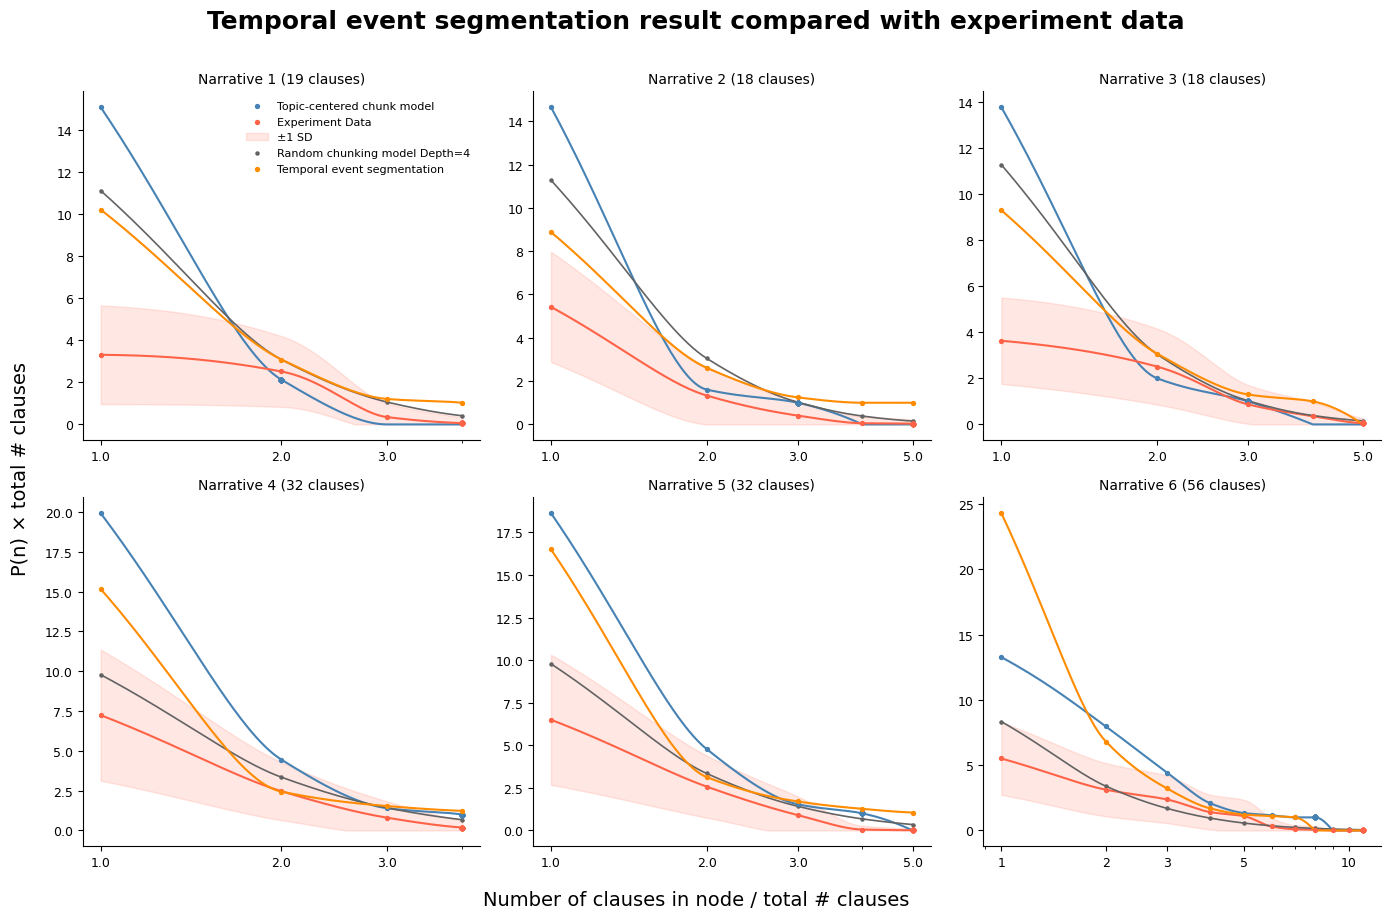

In [56]:
from scipy.interpolate import PchipInterpolator
import numpy as np
from matplotlib.ticker import LogLocator, ScalarFormatter
import matplotlib.pyplot as plt

simulated_data  = y_padded;          simulated_x  = x_padded
experiment_data = y_padded_experiment; experiment_x = x_padded_experiment
colors_theory   = ['#bdbdbd', '#636363']

simulated_fit_data = []; fit_x = []; experiment_fit_data = []
theoretical_layer3 = []; std_data1 = []; std_data2 = []

temporal_x_all, temporal_y_all = [], []
for i in range(len(avg_dict_all_temporal)):
    avg_dict = avg_dict_all_temporal[i]
    tx = sorted(avg_dict.keys())
    ty = [avg_dict[k] for k in tx]
    temporal_x_all.append(tx)
    temporal_y_all.append(ty)

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()
fig.suptitle("Temporal event segmentation result compared with experiment data",
             fontsize=18, fontweight='bold', y=1.01)

for i in range(6):
    ax = axes[i]
    fit_max  = np.max(experiment_x[i])
    fit_min  = max(np.min(experiment_x[i]), np.min(simulated_x[i]))
    x_smooth = np.linspace(fit_min, fit_max, 200)

    # ── Simulated ────────────────────────────────────────────────────────────
    y_sim = pchip_smooth(simulated_x[i], simulated_data[i], x_smooth)
    ax.plot(x_smooth, y_sim, '-', color='steelblue', lw=1.5)
    fit_x.append(x_smooth); simulated_fit_data.append(y_sim)
    mask_sim = np.array(simulated_x[i]) <= fit_max
    ax.scatter(np.array(simulated_x[i])[mask_sim], np.array(simulated_data[i])[mask_sim],
               marker='o', color='steelblue', s=8, zorder=3,
               label='Topic-centered chunk model' if i == 0 else None)

    # ── Experiment ───────────────────────────────────────────────────────────
    y_exp    = pchip_smooth(experiment_x[i], experiment_data[i], x_smooth)
    y_std_hi = pchip_smooth(experiment_x[i], experiment_data[i] + std_padded_experiment[i], x_smooth)
    y_std_lo = pchip_smooth(experiment_x[i], experiment_data[i] - std_padded_experiment[i], x_smooth)
    ax.scatter(experiment_x[i], experiment_data[i], marker='o', color='tomato', s=8, zorder=3,
               label='Experiment Data' if i == 0 else None)
    ax.plot(x_smooth, y_exp, '-', color='tomato', lw=1.5)
    ax.fill_between(x_smooth, y_std_lo, y_std_hi, color='tomato', alpha=0.15,
                    label='±1 SD' if i == 0 else None)
    experiment_fit_data.append(y_exp); std_data1.append(y_std_hi); std_data2.append(y_std_lo)

    # ── Theoretical layers ────────────────────────────────────────────────────
    mask2 = np.array(x_all[i][1]) <= fit_max
    y2    = pchip_smooth(x_all[i][1], P_all[i][1][0], x_smooth)
    theoretical_layer3.append(y2)
    ax.scatter(np.array(x_all[i][1])[mask2], np.array(P_all[i][1][0])[mask2],
               marker='o', color=colors_theory[1], s=5, zorder=2,
               label='Random chunking model Depth=4' if i == 0 else None)
    ax.plot(x_smooth, y2, '-', color=colors_theory[1], lw=1.2)

    # ── Temporal ─────────────────────────────────────────────────────────────
    if i < len(temporal_x_all):
        tx, ty = temporal_x_all[i], temporal_y_all[i]
        if len(tx) >= 2:
            y_t = pchip_smooth(tx, ty, x_smooth)
            ax.plot(x_smooth, y_t, '-', color='darkorange', lw=1.5)
        mask_t = np.array(tx) <= max(x_smooth)
        ax.scatter(np.array(tx)[mask_t], np.array(ty)[mask_t],
                   marker='o', color='darkorange', s=8, zorder=3,
                   label='Temporal event segmentation' if i == 0 else None)

    # ── Styling ───────────────────────────────────────────────────────────────
    ax.set_xscale('log')
    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.xaxis.set_major_locator(LogLocator(base=10, subs=[1, 2, 3, 5]))
    ax.xaxis.set_minor_formatter(plt.NullFormatter())
    ax.tick_params(labelsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_title(f"Narrative {i+1} ({clauses[i]} clauses)", fontsize=10)
    if i == 0:
        ax.legend(fontsize=8, frameon=False)

fig.supxlabel('Number of clauses in node / total # clauses', fontsize=14, y=0.01)
fig.supylabel('P(n) × total # clauses', fontsize=14, x=0.01)
plt.tight_layout()
plt.show()


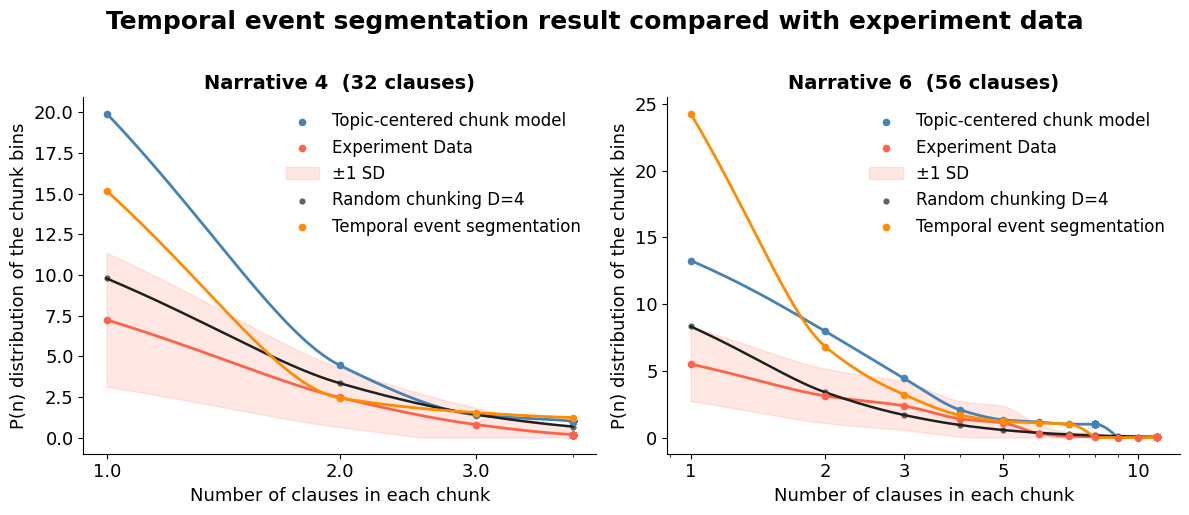

In [59]:
from matplotlib.ticker import LogLocator, ScalarFormatter

story_indices = [3, 5]  # narrative 4 and 6 (0-indexed)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Temporal event segmentation result compared with experiment data",
             fontsize=18, fontweight='bold', y=1.02)

for ax, i in zip(axes, story_indices):
    fit_max  = np.max(experiment_x[i])
    fit_min  = max(np.min(experiment_x[i]), np.min(simulated_x[i]))
    x_smooth = np.linspace(fit_min, fit_max, 200)

    # ── Simulated ────────────────────────────────────────────────────────────
    y_sim = pchip_smooth(simulated_x[i], simulated_data[i], x_smooth)
    ax.plot(x_smooth, y_sim, '-', color='steelblue', lw=2.0)
    mask_sim = np.array(simulated_x[i]) <= fit_max
    ax.scatter(np.array(simulated_x[i])[mask_sim], np.array(simulated_data[i])[mask_sim],
               marker='o', color='steelblue', s=20, zorder=3,
               label='Topic-centered chunk model')

    # ── Experiment ───────────────────────────────────────────────────────────
    y_exp    = pchip_smooth(experiment_x[i], experiment_data[i], x_smooth)
    y_std_hi = pchip_smooth(experiment_x[i], experiment_data[i] + std_padded_experiment[i], x_smooth)
    y_std_lo = pchip_smooth(experiment_x[i], experiment_data[i] - std_padded_experiment[i], x_smooth)
    ax.scatter(experiment_x[i], experiment_data[i], marker='o', color='tomato', s=20, zorder=3,
               label='Experiment Data')
    ax.plot(x_smooth, y_exp, '-', color='tomato', lw=2.0)
    ax.fill_between(x_smooth, y_std_lo, y_std_hi, color='tomato', alpha=0.15, label='±1 SD')

    # ── Theoretical layers ────────────────────────────────────────────────────
    mask2 = np.array(x_all[i][1]) <= fit_max
    y2    = pchip_smooth(x_all[i][1], P_all[i][1][0], x_smooth)
    ax.scatter(np.array(x_all[i][1])[mask2], np.array(P_all[i][1][0])[mask2],
               marker='o', color=colors_theory[1], s=12, zorder=2, label='Random chunking D=4')
    ax.plot(x_smooth, y2, '-', color='#202020', lw=1.8)

    # ── Temporal ─────────────────────────────────────────────────────────────
    if i < len(temporal_x_all):
        tx, ty = temporal_x_all[i], temporal_y_all[i]
        if len(tx) >= 2:
            y_t = pchip_smooth(tx, ty, x_smooth)
            ax.plot(x_smooth, y_t, '-', color='darkorange', lw=2.0)
        mask_t = np.array(tx) <= max(x_smooth)
        ax.scatter(np.array(tx)[mask_t], np.array(ty)[mask_t],
                   marker='o', color='darkorange', s=20, zorder=3,
                   label='Temporal event segmentation')
    
    # ── Styling ───────────────────────────────────────────────────────────────
    ax.set_title(f'Narrative {i+1}  ({clauses[i]} clauses)', fontsize=14, fontweight='bold')
    ax.set_xscale('log')
    ax.xaxis.set_major_locator(LogLocator(base=10, subs=[1, 2, 3, 5]))
    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.xaxis.set_minor_formatter(plt.NullFormatter())
    ax.tick_params(labelsize=13)
    ax.set_xlabel('Number of clauses in each chunk', fontsize=13)
    ax.set_ylabel('P(n) distribution of the chunk bins', fontsize=13)
    ax.legend(fontsize=12, frameon=False)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


In [78]:
n_t = min(len(temporal_x_all), 6)   # first 6 stories

# ── compute smoothed curves on common x grids ─────────────────────────────────
temporal_fit_data2 = []
fit_x_t            = []
theory3_t          = []
exp_fit_t          = []

for i in range(n_t):
    fit_max  = np.max(experiment_x[i])
    fit_min  = max(np.min(experiment_x[i]), np.min(temporal_x_all[i]))
    x_smooth = np.linspace(fit_min, fit_max, 200)
    fit_x_t.append(x_smooth)

    temporal_fit_data2.append(pchip_smooth(temporal_x_all[i], temporal_y_all[i], x_smooth))
    theory3_t.append(pchip_smooth(x_all[i][1], P_all[i][1][0], x_smooth))
    exp_fit_t.append(pchip_smooth(experiment_x[i], experiment_data[i], x_smooth))

# ── number of free parameters ─────────────────────────────────────────────────
k_random   = 0
k_temporal = [len(avg_dict_all_temporal[i]) for i in range(n_t)]  # n event boundaries per story

# ── per-story LL, AIC, BIC ────────────────────────────────────────────────────
results_t = []
for i in range(n_t):
    obs    = exp_fit_t[i]
    n_obs  = len(obs)

    ll_rand = multinomial_loglik(obs, theory3_t[i])
    ll_temp = multinomial_loglik(obs, temporal_fit_data2[i])

    results_t.append(dict(
        story        = i + 1,
        ll_random    = ll_rand,
        ll_temporal  = ll_temp,
        aic_random   = aic(ll_rand, k_random),
        aic_temporal = aic(ll_temp, k_temporal[i]),
        bic_random   = bic(ll_rand, k_random,      n_obs),
        bic_temporal = bic(ll_temp, k_temporal[i], n_obs),
    ))

# ── aggregate ─────────────────────────────────────────────────────────────────
total_ll_rand = sum(r['ll_random']   for r in results_t)
total_ll_temp = sum(r['ll_temporal'] for r in results_t)
total_k_temp  = sum(k_temporal)

total_aic_rand = aic(total_ll_rand, k_random)
total_aic_temp = aic(total_ll_temp, total_k_temp)
total_bic_rand = bic(total_ll_rand, k_random,    n_t)
total_bic_temp = bic(total_ll_temp, total_k_temp, n_t)

# ── report ────────────────────────────────────────────────────────────────────
print("=" * 75)
print("  Temporal Segmentation vs. Random Chunking (first 6 stories)")
print("=" * 75)
print(f"  {'Story':>5}  {'LL_rand':>9}  {'LL_temp':>9}  "
      f"{'AIC_rand':>9}  {'AIC_temp':>9}  {'BIC_rand':>9}  {'BIC_temp':>9}")
print("=" * 75)
for r in results_t:
    better = '<' if r['ll_temporal'] > r['ll_random'] else '>'
    print(f"  {r['story']:>5}  {r['ll_random']:>9.2f}  {r['ll_temporal']:>9.2f}  "
          f"{r['aic_random']:>9.2f}  {r['aic_temporal']:>9.2f}  "
          f"{r['bic_random']:>9.2f}  {r['bic_temporal']:>9.2f}  {better}")
print("=" * 75)
print(f"  Total  {total_ll_rand:>9.2f}  {total_ll_temp:>9.2f}  "
      f"{total_aic_rand:>9.2f}  {total_aic_temp:>9.2f}  "
      f"{total_bic_rand:>9.2f}  {total_bic_temp:>9.2f}")
print("=" * 75)
print(f"\n  ΔAIC (temporal − random) = {total_aic_temp - total_aic_rand:.2f}")
print(f"  ΔBIC (temporal − random) = {total_bic_temp - total_bic_rand:.2f}")
print(f"  (negative = temporal is better; >10 = strong evidence)")


  Temporal Segmentation vs. Random Chunking (first 6 stories)
  Story    LL_rand    LL_temp   AIC_rand   AIC_temp   BIC_rand   BIC_temp
      1   -1513.43   -1521.12    3026.85    3050.25    3026.85    3063.44  >
      2    -935.64    -960.04    1871.29    1932.08    1871.29    1951.87  >
      3   -1376.00   -1370.23    2752.00    2748.47    2752.00    2761.66  <
      4   -2133.43   -2150.53    4266.86    4323.07    4266.86    4359.35  >
      5   -1508.48   -1532.57    3016.96    3079.14    3016.96    3102.23  >
      6   -1014.88   -1038.27    2029.76    2090.55    2029.76    2113.64  >
  Total   -8481.86   -8572.77   16963.72   17223.55   16963.72   17215.43

  ΔAIC (temporal − random) = 259.82
  ΔBIC (temporal − random) = 251.70
  (negative = temporal is better; >10 = strong evidence)
